# TP Final Ciencia Datos R: Fundamentos estadisticos

https://www.kaggle.com/code/aditimulye/imdb-5000-movie-dataset-analysis/data

https://www.kaggle.com/code/tanetboss/beginner-binary-classification-for-nice-movie/notebook

https://www.kaggle.com/code/bharathraja/statistical-approach-for-predicting-imdb/notebook

https://www.kaggle.com/code/carolzhangdc/predict-imdb-score-with-data-mining-algorithms

## NUEVAS TAREAS

*   Probar binarizarlo. que binarizacion da mejores resultados?
*   ROC a las variables para saber cuales son las mejores para clasificar
*   Knn + probar logistica o naive


## Introduccion

### Disparador

Las peliculas ademas de generarnos gran entretenimiento tambien son una industria que mueve millones de dolares. Hay muchos variables que son importantes en la creacion de las peliculas generan que las mismas sean buenas o malas, como la experiencia del director o actores.
Sin embargo, estas condiciones pueden no generar una buena puntuacion dentro del publico como lo es el score de IMDB


## Data Description
El dataset es de Kaggle, contiene 28 variables de 5043 peliculas, a lo largo de 100 años en 66 paises.
Hay 2399 directores unicos y miles de actores y actrices


“imdb_score” is the response variable while the other 27 variables are possible predictors.

In [ ]:
# Para descargar el DF a entorno de colab
system("ls", TRUE)
system("gdown --id 1f6ZCKqDRvon66PlQHUeR-4rEtLKUioLB")

[1] "movie_metadata.csv" "sample_data"

In [ ]:
# Cargamos el DF
df <-  read.csv("movie_metadata.csv")

In [ ]:
# Hacemos un str del df para ver las variables
str(df)

'data.frame':	5043 obs. of  28 variables:
 $ color                    : chr  "Color" "Color" "Color" "Color" ...
 $ director_name            : chr  "James Cameron" "Gore Verbinski" "Sam Mendes" "Christopher Nolan" ...
 $ num_critic_for_reviews   : int  723 302 602 813 NA 462 392 324 635 375 ...
 $ duration                 : int  178 169 148 164 NA 132 156 100 141 153 ...
 $ director_facebook_likes  : int  0 563 0 22000 131 475 0 15 0 282 ...
 $ actor_3_facebook_likes   : int  855 1000 161 23000 NA 530 4000 284 19000 10000 ...
 $ actor_2_name             : chr  "Joel David Moore" "Orlando Bloom" "Rory Kinnear" "Christian Bale" ...
 $ actor_1_facebook_likes   : int  1000 40000 11000 27000 131 640 24000 799 26000 25000 ...
 $ gross                    : int  760505847 309404152 200074175 448130642 NA 73058679 336530303 200807262 458991599 301956980 ...
 $ genres                   : chr  "Action|Adventure|Fantasy|Sci-Fi" "Action|Adventure|Fantasy" "Action|Adventure|Thriller" "Action|Thrille

In [ ]:
# Reordenamos las variables
df <- df[, c('movie_title','imdb_score','director_name','genres','actor_1_name','duration','language','country','content_rating','budget','gross','title_year','color','num_critic_for_reviews','director_facebook_likes','actor_3_facebook_likes','actor_2_name','actor_1_facebook_likes','num_voted_users','cast_total_facebook_likes','actor_3_name','facenumber_in_poster','plot_keywords','movie_imdb_link','num_user_for_reviews','actor_2_facebook_likes','aspect_ratio','movie_facebook_likes')] # leave the row index blank to keep all rows
head(df)

,movie_title,imdb_score,director_name,genres,actor_1_name,duration,language,country,content_rating,budget,⋯,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,actor_2_facebook_likes,aspect_ratio,movie_facebook_likes
,<chr>,<dbl>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,⋯,<int>,<int>,<chr>,<int>,<chr>,<chr>,<int>,<int>,<dbl>,<int>
1,Avatar,7.9,James Cameron,Action|Adventure|Fantasy|Sci-Fi,CCH Pounder,178,English,USA,PG-13,237000000,⋯,886204,4834,Wes Studi,0,avatar|future|marine|native|paraplegic,http://www.imdb.com/title/tt0499549/?ref_=fn_tt_tt_1,3054,936,1.78,33000
2,Pirates of the Caribbean: At World's End,7.1,Gore Verbinski,Action|Adventure|Fantasy,Johnny Depp,169,English,USA,PG-13,300000000,⋯,471220,48350,Jack Davenport,0,goddess|marriage ceremony|marriage proposal|pirate|singapore,http://www.imdb.com/title/tt0449088/?ref_=fn_tt_tt_1,1238,5000,2.35,0
3,Spectre,6.8,Sam Mendes,Action|Adventure|Thriller,Christoph Waltz,148,English,UK,PG-13,245000000,⋯,275868,11700,Stephanie Sigman,1,bomb|espionage|sequel|spy|terrorist,http://www.imdb.com/title/tt2379713/?ref_=fn_tt_tt_1,994,393,2.35,85000
4,The Dark Knight Rises,8.5,Christopher Nolan,Action|Thriller,Tom Hardy,164,English,USA,PG-13,250000000,⋯,1144337,106759,Joseph Gordon-Levitt,0,deception|imprisonment|lawlessness|police officer|terrorist plot,http://www.imdb.com/title/tt1345836/?ref_=fn_tt_tt_1,2701,23000,2.35,164000
5,Star Wars: Episode VII - The Force Awakens,7.1,Doug Walker,Documentary,Doug Walker,NA,,,,NA,⋯,8,143,,0,,http://www.imdb.com/title/tt5289954/?ref_=fn_tt_tt_1,NA,12,NA,0
6,John Carter,6.6,Andrew Stanton,Action|Adventure|Sci-Fi,Daryl Sabara,132,English,USA,PG-13,263700000,⋯,212204,1873,Polly Walker,1,alien|american civil war|male nipple|mars|princess,http://www.imdb.com/title/tt0401729/?ref_=fn_tt_tt_1,738,632,2.35,24000


In [ ]:
# Chequeamos si hay filas duplicadas
print(dim(df))
print('Removemos Filas duplicadas')
sum(duplicated(df)) # 45 Duplicated Rows
df <- df[!duplicated(df), ]
dim(df)

[1] 5043   28
[1] "Removemos Filas duplicadas"


[1] 45

[1] 4998   28

## Data Cleaning
### 3.1 Missing Values

To find missing values in each column, we use colSums() function to aggregate NA in each column.



In [ ]:
# Miramos Si hay valores faltanes
colSums(sapply(df, is.na))
# str(df['imdb_score'])
# hist(df['imdb_score'])

movie_title                imdb_score             director_name 
                        0                         0                         0 
                   genres              actor_1_name                  duration 
                        0                         0                        15 
                 language                   country            content_rating 
                        0                         0                         0 
                   budget                     gross                title_year 
                      487                       874                       107 
                    color    num_critic_for_reviews   director_facebook_likes 
                        0                        49                       103 
   actor_3_facebook_likes              actor_2_name    actor_1_facebook_likes 
                       23                         0                         7 
          num_voted_users cast_total_facebook_likes              actor_3_name 
                        0                         0                         0 
     facenumber_in_poster             plot_keywords           movie_imdb_link 
                       13                         0                         0 
     num_user_for_reviews    actor_2_facebook_likes              aspect_ratio 
                       21                        13                       327 
     movie_facebook_likes 
                        0

Las variables mas importantes que tienen valores ausentes son Budget y Gross
El resto de las variables poseen pocos o nulos valores ausentes

In [ ]:
# Descartamos las budget y gross que tenian valores nulos
df <- df[!is.na(df$gross), ]
df<- df[!is.na(df$budget), ]
dim(df)
colSums(sapply(df, is.na))


[1] 3857   28

movie_title                imdb_score             director_name 
                        0                         0                         0 
                   genres              actor_1_name                  duration 
                        0                         0                         1 
                 language                   country            content_rating 
                        0                         0                         0 
                   budget                     gross                title_year 
                        0                         0                         0 
                    color    num_critic_for_reviews   director_facebook_likes 
                        0                         1                         0 
   actor_3_facebook_likes              actor_2_name    actor_1_facebook_likes 
                       10                         0                         3 
          num_voted_users cast_total_facebook_likes              actor_3_name 
                        0                         0                         0 
     facenumber_in_poster             plot_keywords           movie_imdb_link 
                        6                         0                         0 
     num_user_for_reviews    actor_2_facebook_likes              aspect_ratio 
                        0                         5                        74 
     movie_facebook_likes 
                        0

In [ ]:
# Calculamos la ganancia de cada pelicula para trabajar con una variable en lugar de 2
df['profit'] = df['budget']/df['gross']

# Miramos las categorias de content rating
table(df['content_rating'])

content_rating
           Approved         G        GP         M     NC-17 Not Rated    Passed 
       51        17        91         1         2         6        42         3 
       PG     PG-13         R   Unrated         X 
      573      1314      1723        24        10 

In [ ]:
df_sub <- df[df$content_rating %in% c("PG-13", "PG", "R"),]

## Armado de df para guia


In [ ]:
# According to the history of naming these different content ratings, we find M = GP = PG, X = NC-17.
# We want to replace M and GP with PG, replace X with NC-17, because these two are what we use nowadays.
# https://help.imdb.com/article/contribution/titles/certificates/GU757M8ZJ9ZPXB39#
df$content_rating[df$content_rating == 'M'] <- 'PG'
df$content_rating[df$content_rating == 'GP']  <- 'PG'
# df$content_rating[df$content_rating == 'X']   <- 'NC-17'
table(df['content_rating'])


content_rating
           Approved         G     NC-17 Not Rated    Passed        PG     PG-13 
       51        17        91         6        42         3       576      1314 
        R   Unrated         X 
     1723        24        10 

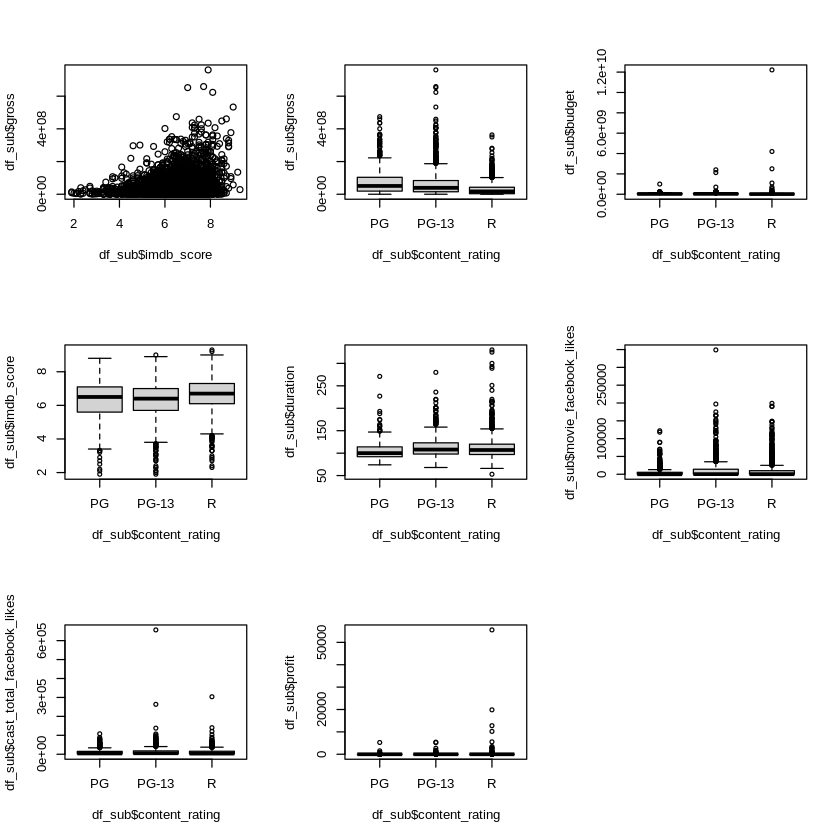

In [ ]:
# Nos que damos con las categorias mas representativas
# attach(df)
# df_sub=df[which(df$content_rating==c("PG-13", "PG", "R")),]
df_sub <- df[df$content_rating %in% c("PG-13", "PG", "R"),]

# attach(df_sub)

# Ploteamos varios graficos
par(mfrow=c(3,3))
plot(df_sub$imdb_score,df_sub$gross)
boxplot(df_sub$gross ~ df_sub$content_rating)
boxplot(df_sub$budget ~ df_sub$content_rating)
boxplot(df_sub$imdb_score ~ df_sub$content_rating)
boxplot(df_sub$duration ~ df_sub$content_rating)
boxplot(df_sub$movie_facebook_likes ~ df_sub$content_rating)
boxplot(df_sub$cast_total_facebook_likes ~ df_sub$content_rating)
boxplot(df_sub$profit ~ df_sub$content_rating)

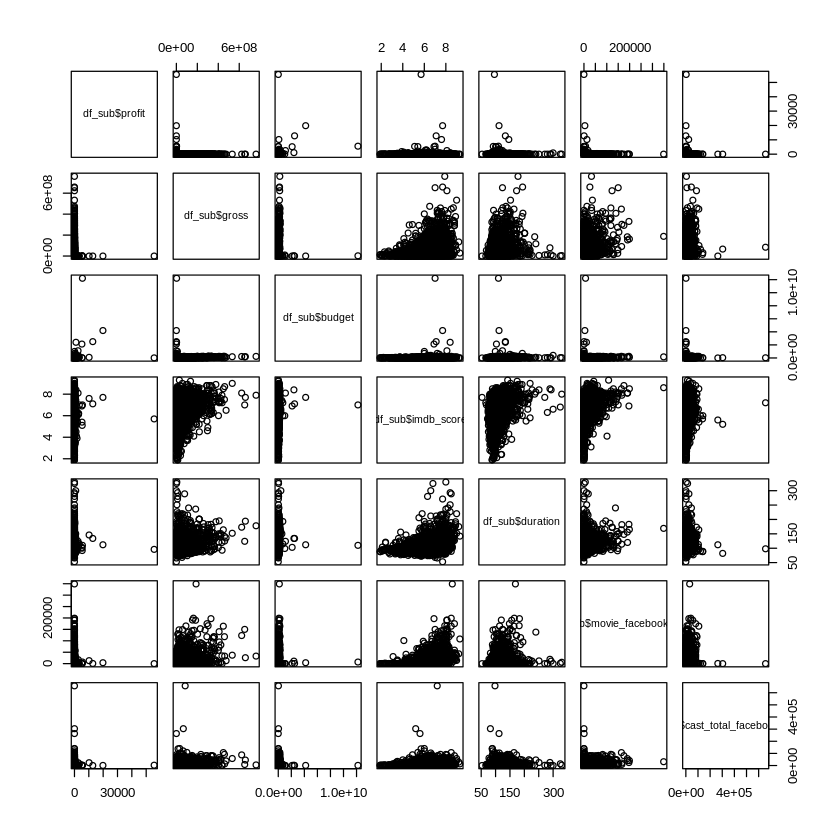

In [ ]:
library('ggplot2')
# attach(df)
pairs(~  df_sub$profit + df_sub$gross + df_sub$budget+ df_sub$imdb_score +df_sub$duration+ df_sub$movie_facebook_likes + df_sub$cast_total_facebook_likes)

[1] 2588

                                            movie_title imdb_score
941 Interview with the Vampire: The Vampire Chronicles         7.6
    director_name               genres actor_1_name duration language country
941   Neil Jordan Drama|Fantasy|Horror    Brad Pitt      123  English     USA
    content_rating budget     gross title_year color num_critic_for_reviews
941              R  6e+07 105264608       1994 Color                    120
    director_facebook_likes actor_3_facebook_likes actor_2_name
941                     277                   4000   Tom Cruise
    actor_1_facebook_likes num_voted_users cast_total_facebook_likes
941                  11000          239752                     25697
     actor_3_name facenumber_in_poster
941 Kirsten Dunst                    0
                                                 plot_keywords
941 betrayal|dangerous friend|gothic|monster as victim|vampire
                                         movie_imdb_link num_user_for_reviews
941 http:/

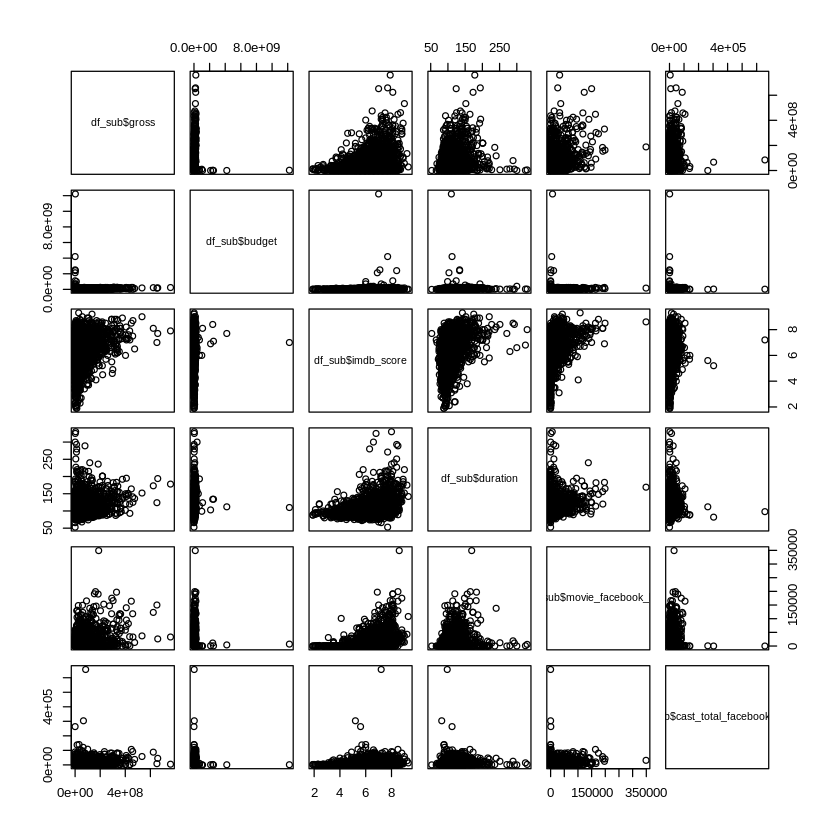

In [ ]:
which(df_sub$budget==max(df_sub$budget))
print(df_sub[859,])
df_sub=df_sub[-859,]
pairs(~ df_sub$gross + df_sub$budget+ df_sub$imdb_score +df_sub$duration+ df_sub$movie_facebook_likes + df_sub$cast_total_facebook_likes)

In [ ]:
which(df_sub$budget == max(df_sub$budget))
print(df_sub[864,])
# df_sub= df_sub[-864,]

[1] 2587

    movie_title imdb_score director_name                       genres
947 Inside Man         7.6     Spike Lee Crime|Drama|Mystery|Thriller
         actor_1_name duration language country content_rating  budget    gross
947 Denzel Washington      129  English     USA              R 4.5e+07 88504640
    title_year color num_critic_for_reviews director_facebook_likes
947       2006 Color                    230                       0
    actor_3_facebook_likes  actor_2_name actor_1_facebook_likes num_voted_users
947                    277 James Ransone                  18000          273108
    cast_total_facebook_likes actor_3_name facenumber_in_poster
947                     19148 Peter Gerety                    2
                               plot_keywords
947 bank|detective|negotiation|police|robber
                                         movie_imdb_link num_user_for_reviews
947 http://www.imdb.com/title/tt0454848/?ref_=fn_tt_tt_1                  646
    actor_2_facebook_likes asp

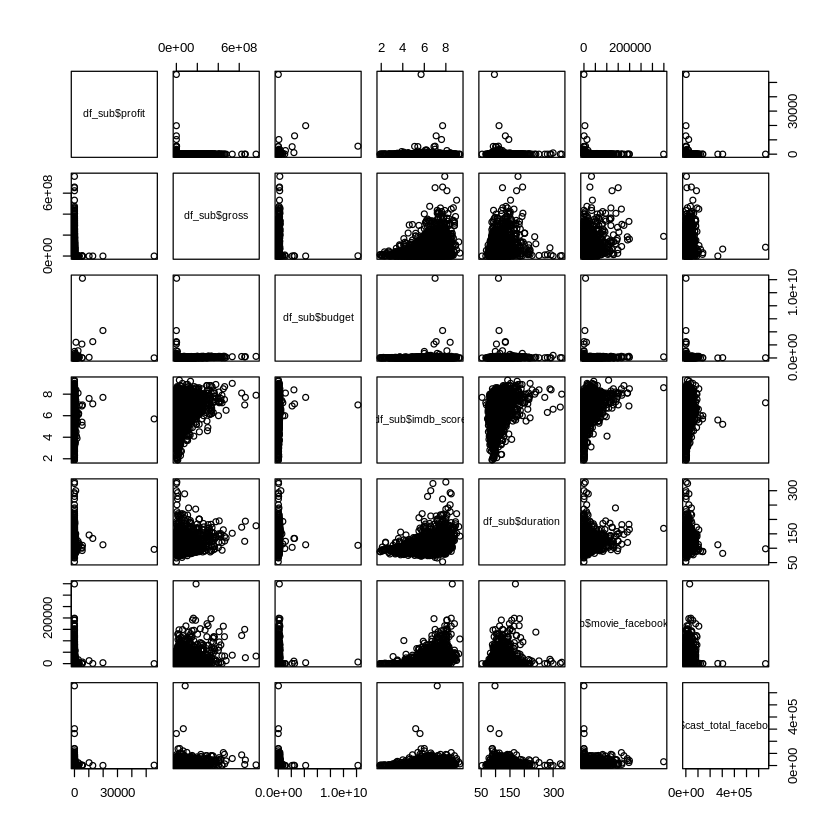

In [ ]:
pairs(~  df_sub$profit + df_sub$gross + df_sub$budget+ df_sub$imdb_score +df_sub$duration+ df_sub$movie_facebook_likes + df_sub$cast_total_facebook_likes)

In [ ]:
names(df_sub)

[1] "movie_title"               "imdb_score"               
 [3] "director_name"             "genres"                   
 [5] "actor_1_name"              "duration"                 
 [7] "language"                  "country"                  
 [9] "content_rating"            "budget"                   
[11] "gross"                     "title_year"               
[13] "color"                     "num_critic_for_reviews"   
[15] "director_facebook_likes"   "actor_3_facebook_likes"   
[17] "actor_2_name"              "actor_1_facebook_likes"   
[19] "num_voted_users"           "cast_total_facebook_likes"
[21] "actor_3_name"              "facenumber_in_poster"     
[23] "plot_keywords"             "movie_imdb_link"          
[25] "num_user_for_reviews"      "actor_2_facebook_likes"   
[27] "aspect_ratio"              "movie_facebook_likes"     
[29] "profit"

In [ ]:
# df_def=scale(df[,c("budget","gross", "imdb_score", "duration","movie_facebook_likes", "cast_total_facebook_likes")])
# df_def=cbind(df_def, df["content_rating"])
# colnames(df_def)[7]="content_rating"

df_def=scale(df_sub[,c("profit","budget","gross", "imdb_score", "duration","movie_facebook_likes", "cast_total_facebook_likes")])
df_def=cbind(df_def, df_sub["content_rating"])
colnames(df_def)[8]="content_rating"
df_def

,profit,budget,gross,imdb_score,duration,movie_facebook_likes,cast_total_facebook_likes,content_rating
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,-0.04905600,0.8275144,10.2377446,1.39091318,3.0704300,1.07711845,-0.35646410,PG-13
2,-0.04842514,1.1011044,3.7206890,0.62678095,2.6617801,-0.43505905,1.89367489,PG-13
3,-0.04818071,0.8622560,2.1412014,0.34023136,1.7082639,3.45994360,-0.00143482,PG-13
4,-0.04881991,0.8839695,5.7248674,1.96401235,2.4347525,7.08000489,4.91390579,PG-13
6,-0.04589412,0.9434645,0.3062115,0.14919830,0.9817753,0.66470641,-0.50957242,PG-13
7,-0.04861974,0.9187111,4.1125799,-0.23286782,2.0715082,-0.43505905,1.77500431,PG-13
8,-0.04811338,0.9273965,2.1517923,1.29539665,-0.4712019,0.89382421,-0.50114397,PG
9,-0.04883256,0.8839695,5.8817754,1.00884706,1.3904251,4.97212110,4.15074279,PG-13
10,-0.04856098,0.8839695,3.6130999,1.00884706,1.9352916,0.02317656,2.43159648,PG


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘Rcpp’, ‘plyr’, ‘reshape’


Registered S3 method overwritten by 'GGally':
  method from   
  +.gg   ggplot2

Warning message in ggcorr(df_def, label = TRUE, label_round = 2, label_size = 3.5, :
“data in column(s) 'content_rating' are not numeric and were ignored”


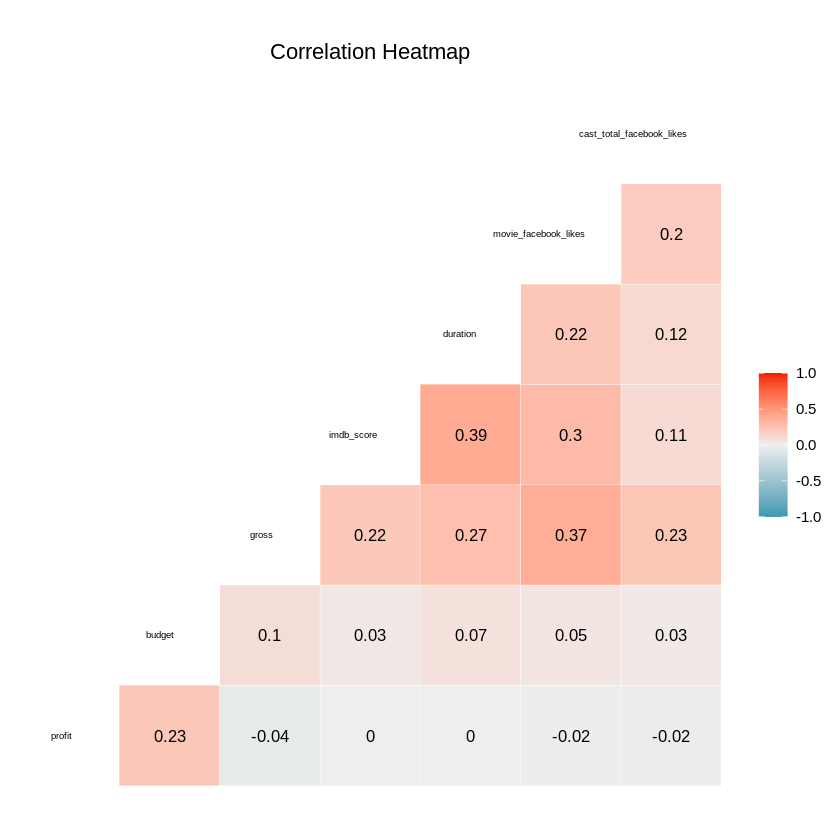

In [ ]:
install.packages("GGally")
library(GGally)
ggcorr(df_def, label = TRUE, label_round = 2, label_size = 3.5, size = 2, hjust = .85) +
  ggtitle("Correlation Heatmap") +
  theme(plot.title = element_text(hjust = 0.5))

## *Guia*


Ajustar Las columnas de profit.

Hacer plot correlacion variables Para elegir explicatorias

Luego KNN

### Sin libreria

In [ ]:
dist_euclidea <- function (vector1, vector2){
  distancia <- sqrt(sum((vector1 - vector2)^2))
  # Calcula la distancia entre elemento del Test y elemento del Train (distancia entre vectores)
  distancia
}

a <- c(2, 6, 7, 7, 5, 13, 14, 17, 11, 8)
b <- c(3, 5, 5, 3, 7, 12, 13, 19, 22, 7)
dist_euclidea(a,b)

[1] 12.40967

In [ ]:
# 2. Explorar el comando dist de la libreria stats. Calcular nuevamente la distancia. Chequear con el punto 1.
# compute the Euclidean Distance using R's base function
x <- rbind(a,b)
stats::dist(x, method = "euclidean")

         a
b 12.40967

In [ ]:
# 3.
install.packages('philentropy')
library(philentropy)
getDistMethods()

ProbMatrix <- rbind(1:10/sum(1:10), 20:29/sum(20:29),30:39/sum(30:39))
rownames(ProbMatrix) <- paste0("Example", 1:3)
ProbMatrix
print('Con el metodo distance')
distance(ProbMatrix, method = "euclidean", use.row.names = TRUE)
print('Con el metodo stats::dist')
stats::dist(ProbMatrix, method = "euclidean")

print('Whereas distance() returns a symmetric distance matrix, stats::dist() returns only one part of the symmetric matrix.')
# Try as.dist.obj = TRUE en calculo de distancia

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘poorman’


Warning message in install.packages("philentropy"):
“installation of package ‘philentropy’ had non-zero exit status”


ERROR: ignored

In [ ]:
dist_euclidea_muchos <- function (vectorTest, dfTrain){
  # Calcula la distancia para cada elemento del Train la distancia con el vectortest (llamando a dist_euclidea)
  # agrega vectorcondistancias al dfTrain
  distancias=c()
  for (i in 1:dim(dfTrain)[1]){
    dist = dist_euclidea(vectorTest, (dfTrain[i,1:3]))
    distancias=c(distancias, dist)
  }
  dfTrain$distancias=distancias
  return (dfTrain)
}

In [ ]:
dist_euclidea_muchos <- function (vectorTest, dfTrain){
  # Calcula la distancia para cada elemento del Train la distancia con el vectortest (llamando a dist_euclidea)
  # agrega vectorcondistancias al dfTrain
  dfTrain$distancias <- apply(dfTrain[,1:3], 1, function(x)sqrt(sum((x-vectorTest)^2)))
  dfTrain
}

In [ ]:
clasif_item_test <- function (vectorTest, dfTrain, kvec){
  # Procesa el resultado de dist_euclidea_muchos (llamando a dist_euclidea_muchos)
  # Ordena el DF por la columna distancia euclidea, corta en el K, y clasifica segun proporcion de los elementos
  dfTrain=dist_euclidea_muchos(vectorTest, dfTrain)
  print(dfTrain)
  dfTrain=dfTrain[order(dfTrain$distancias),]
  tabla=table(dfTrain[1:kvec,"content_rating"])
  return (names(tabla[order(tabla, decreasing = TRUE)])[1])
}

In [ ]:
clasif_test_muchos <- function (dfTest, dfTrain, kvec){
  # LLama a clasif_item_test y agrega el valor de la prediccion a dftest(new column)
  outputs=c()
  print(dim(dfTest)[1])
  for(vecTest in 1:dim(dfTest)[1]){
    print(dfTest[vecTest,1:3])
    out=clasif_item_test(dfTest[vecTest,1:3], dfTrain, kvec) # pasar valores de los parametros con los que clasificara
    outputs=c(outputs, out)
  }
  dfTest$clasificacion=outputs
  return (dfTest)
}


In [ ]:
error_clasif <- function (dfTest){
  # Calcula el error de la clasificacion empirico entre la clasif y la prediccion
  return (mean(dfTest$clasificacion != dfTest$content_rating))
}

In [ ]:
cross_validation <- function (df, kfold, kvec){
  # Separa en k segmentos, llama clasif_test_muchos para cada segmento como dfTest y clasifica,
  # luego calcula el error
  # luego promedio de cada segmento
  rows=dim(df)[1] %/% kfold
  indices=seq(1, dim(df)[1], by=1) # obtengo los indices de mi df
  shuffled_indices=sample(indices, replace=FALSE) # hago una mezcla de indices
  for (k in 1:kfold){
    print(k)
    test_indices=shuffled_indices[(1+(k-1)*rows):(k*rows)] # me quedo con los indices que seran utilizados para el test
    train_indices=shuffled_indices[which(!shuffled_indices %in% test_indices)]
    test_result=clasif_test_muchos(df[test_indices,], df[train_indices,], kvec)
    print(error_clasif(test_result))
  }
}
df_cross= df_def[,c("profit", "duration", "cast_total_facebook_likes","content_rating")]
df_def
#cross_validation(df_cross, 5, 10)

In [ ]:
grafico_error_kvecinos <- function (df, kfold, maxvecinos){
  # hace el cross-validation para cada kvec
  # plotea el ecme vs Kvecinos
  errores<- c()
  for (kvec in 5:maxvecinos){
    print('kvec')
    print(kvec)
    errores <- c(errores,cross_validation(df, 5, kvec))
  }
  errores
}

errores <- grafico_error_kvecinos(df_cross, 5, 10)
k<-5:10
plot(errores2,1:5)

### Con libreria

In [ ]:
error_clasif <- function (dfTest){
  # Calcula el error de la clasificacion empirico entre la clasif y la prediccion
  return (mean(dfTest$clasificacion != dfTest$content_rating))
}

# Version usando libreria
library (class)


cross_validation_paq <- function (df, kfold, kvec){
  rows=dim(df)[1] %/% kfold
  indices=seq(1, dim(df)[1], by=1) # obtengo los indices de mi df
  shuffled_indices=sample(indices, replace=FALSE) # hago una mezcla de indices
  errores_k <- c()
  for (k in 1:kfold){
    test_indices=shuffled_indices[(1+(k-1)*rows):(k*rows)] # me quedo con los indices que seran utilizados para el test
    train_indices=shuffled_indices[which(!shuffled_indices %in% test_indices)]
    df_train <- df[train_indices,]
    df_test <- df[test_indices,]
    train.X <- df_train[,1:7]
    train.vector = df_train[,"content_rating"]
    test.X <- df_test[,1:7]
    knn.pred <- knn (train.X, test.X, train.vector , k = kvec)
    df_test$clasificacion = knn.pred
    errores_k <- c(errores_k,error_clasif(df_test))
  }
  if(kvec==20){
    print(mean(errores_k))
  }
  errores_k
}

df_def=scale(df_sub[,c("profit","budget","gross", "imdb_score", "duration","movie_facebook_likes", "cast_total_facebook_likes")])
df_def=cbind(df_def, df_sub["content_rating"])
colnames(df_def)[8]="content_rating"
df_def
df_cross= df_def[,c("profit","budget","gross", "imdb_score", "duration","movie_facebook_likes", "cast_total_facebook_likes","content_rating")]
# df_def=scale(df_sub[,c("profit","budget","gross", "imdb_score", "duration","movie_facebook_likes", "cast_total_facebook_likes")])
# df_def
cross_validation_paq(df_cross, 5, 10)

,profit,budget,gross,imdb_score,duration,movie_facebook_likes,cast_total_facebook_likes,content_rating
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,-0.04905600,0.8275144,10.2377446,1.39091318,3.0704300,1.07711845,-0.35646410,PG-13
2,-0.04842514,1.1011044,3.7206890,0.62678095,2.6617801,-0.43505905,1.89367489,PG-13
3,-0.04818071,0.8622560,2.1412014,0.34023136,1.7082639,3.45994360,-0.00143482,PG-13
4,-0.04881991,0.8839695,5.7248674,1.96401235,2.4347525,7.08000489,4.91390579,PG-13
6,-0.04589412,0.9434645,0.3062115,0.14919830,0.9817753,0.66470641,-0.50957242,PG-13
7,-0.04861974,0.9187111,4.1125799,-0.23286782,2.0715082,-0.43505905,1.77500431,PG-13
8,-0.04811338,0.9273965,2.1517923,1.29539665,-0.4712019,0.89382421,-0.50114397,PG
9,-0.04883256,0.8839695,5.8817754,1.00884706,1.3904251,4.97212110,4.15074279,PG-13
10,-0.04856098,0.8839695,3.6130999,1.00884706,1.9352916,0.02317656,2.43159648,PG


[1] 0.4612188 0.4570637 0.4653740 0.4556787 0.4321330

[1] 0.4515235 0.4376731 0.4529086 0.4445983 0.4155125

[1] 0.433795
[1] "ECM"


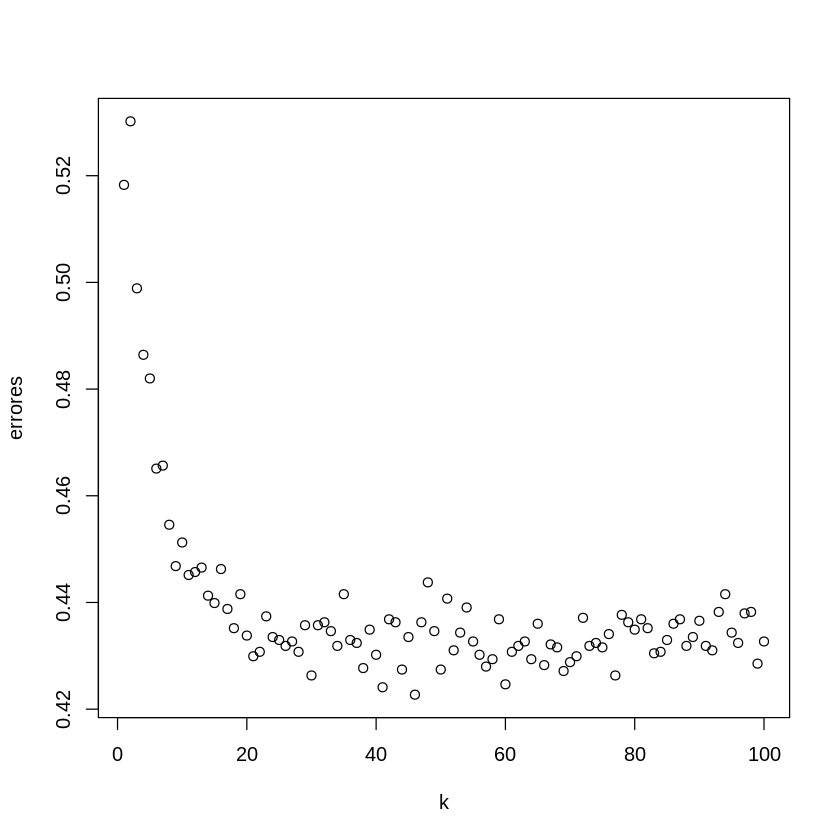

In [ ]:
grafico_error_kvecinos_paq <- function (df, kfold, maxvecinos){
  # hace el cross-validation para cada kvec
  # plotea el ecme vs Kvecinos
  errores<- c()
  for (kvec in 1:maxvecinos){
    # print('kvec')
    # print(kvec)
    errores <- c(errores,mean(cross_validation_paq(df, 5, kvec)))
    if(kvec==20){
      print("ECM")
    }
  }
  errores
}


cross_validation_paq(df_cross, 5, 10)
maximo_vecinos <- 100
errores <- grafico_error_kvecinos_paq(df_cross, 5, maximo_vecinos)

# Grafico
k<-1:maximo_vecinos
df2<-data.frame(k,errores)
# df2
plot(k, errores)

## Que Binarizacion da mejores resultados? KNN

Correr Modulo data description, data cleaning y guia con libreria (minimizar modulo y correr todo junto)

In [ ]:
corrida_knn <- function (df ){
    maximo_vecinos <- 100
    kfold <- 5
    df= df[,c("profit","budget","gross", "imdb_score", "duration","movie_facebook_likes", "cast_total_facebook_likes","content_rating")]
    df_def=scale(df[,c("profit","budget","gross", "imdb_score", "duration","movie_facebook_likes", "cast_total_facebook_likes")])
    df_def=cbind(df_def, df["content_rating"])
    colnames(df_def)[8]="content_rating"
    errores <- grafico_error_kvecinos_paq(df_def, 5, maximo_vecinos)
    # Grafico
    k<-1:maximo_vecinos
    plot(k, errores)
}

content_rating
  PG    R 
 576 1722 

[1] 0.2034858
[1] "ECM"


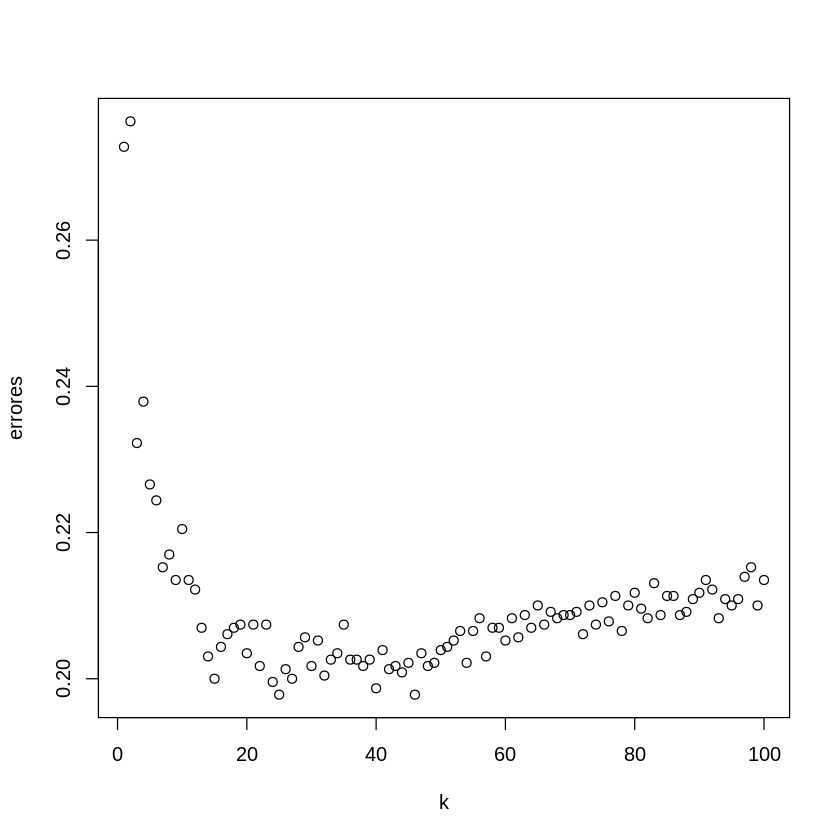

In [ ]:
# 1) DATAFRAME df_PG_17 donde queda PG vs R
df_PG_17 <- df_def[df_def$content_rating %in% c("PG","R"),]
table(df_PG_17['content_rating'])

# KNN
corrida_knn(df_PG_17)

content_rating
   PG PG-13 
  576  1314 

[1] 0.2756614
[1] "ECM"


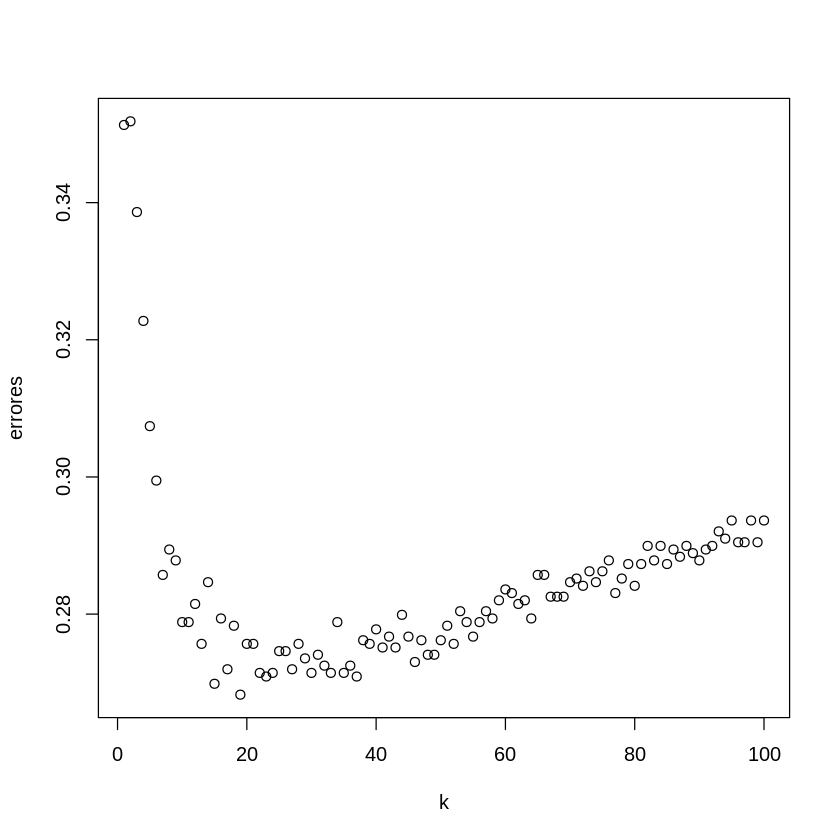

In [ ]:
# 2) DATAFRAME donde queda PG vs PG-13
df_PG_13 <- df_def[df_def$content_rating %in% c("PG","PG-13"),]
table(df_PG_13['content_rating'])

# KNN
corrida_knn(df_PG_13)

content_rating
PG-13     R 
 1314  1722 

[1] 0.3446458
[1] "ECM"


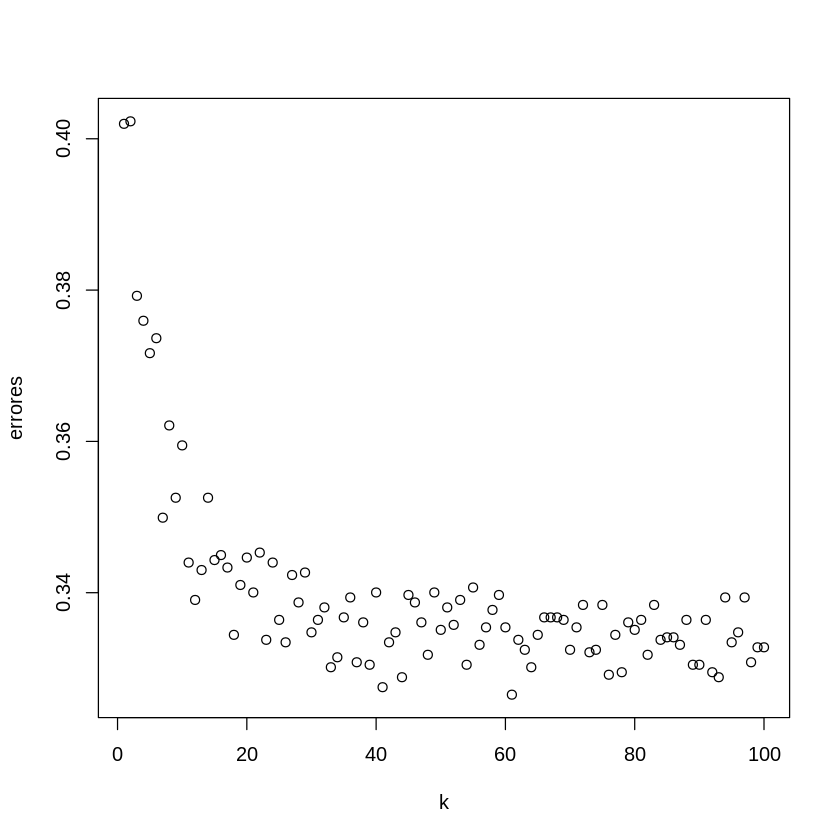

In [ ]:
# 3) DATAFRAME donde queda PG-13 vs R
df_13_R <- df_def[df_def$content_rating %in% c("R","PG-13"),]
table(df_13_R['content_rating'])

# KNN
corrida_knn(df_13_R)

content_rating
  PG    R 
1890 1722 

[1] 0.3498615
[1] "ECM"


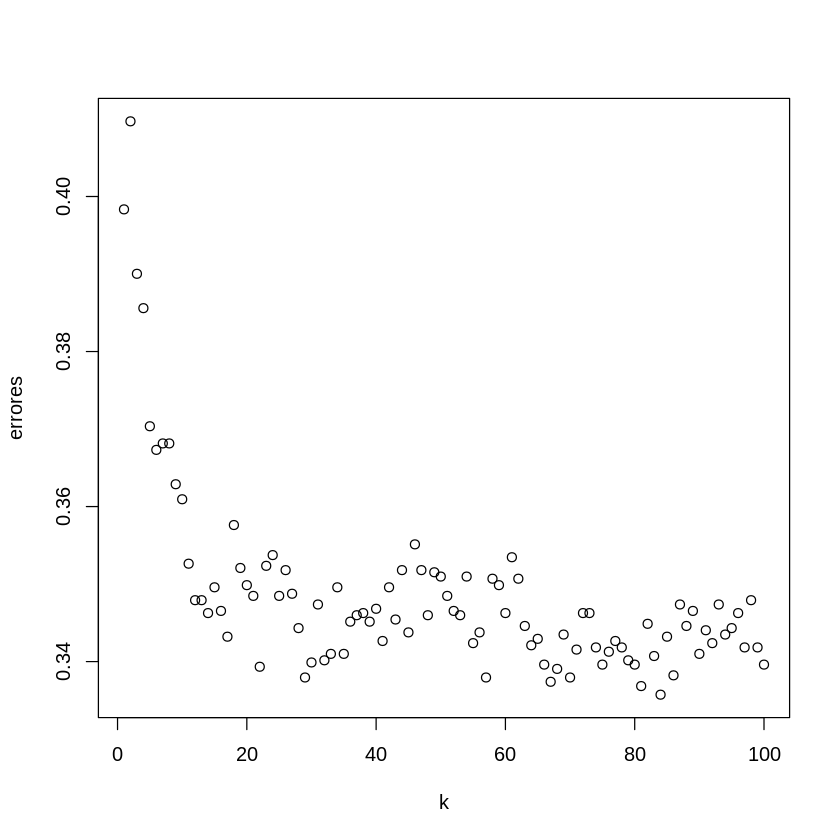

In [ ]:
# 4) DATAFRAME df_PGy13_17 donde se juntan PG y PG-13 vs R
df_PGy13_17 <- df_def[df_def$content_rating %in% c("PG","R","PG-13"),]
df_PGy13_17$content_rating[df_PGy13_17$content_rating == 'PG-13'] <- 'PG'
table(df_PGy13_17['content_rating'])

# KNN
corrida_knn(df_PGy13_17)

content_rating
  PG    R 
 576 3036 

[1] 0.1493075
[1] "ECM"


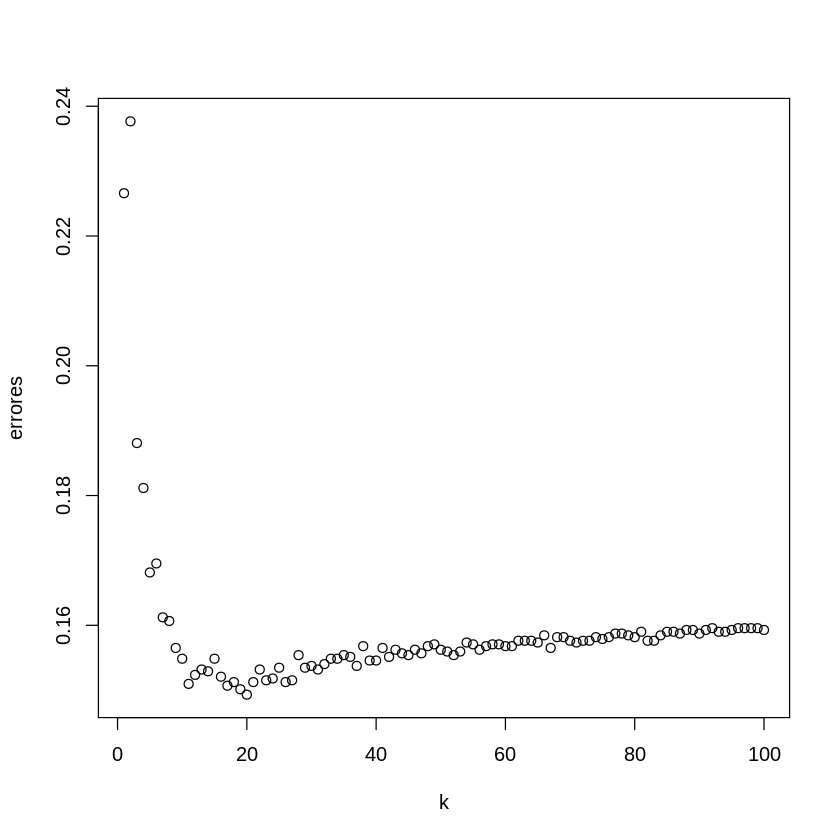

In [ ]:
# 5) DATAFRAME df_PG_13y17 donde se juntan R y PG-13 vs PG
df_PG_13y17 <- df_def[df_def$content_rating %in% c("PG","R","PG-13"),]
df_PG_13y17$content_rating[df_PG_13y17$content_rating == 'PG-13'] <- 'R'
table(df_PG_13y17['content_rating'])

# KNN
corrida_knn(df_PG_13y17)

### Bias-Variance Trade-off

La celda de abajo es anecdotica. Es el mismo plot de recien de los errores del test set por cada k (en color azul), pero tiene ademas los errores del training set (en color rojo). Lo llamativo es la forma de U que forman los puntos del test set, mientras que el training set va en constante decrecimiento. Lo que muestra esto es el trade-off sesgo-varianza. Cuanto menor es la cantidad de vecinos, mas flexible el modelo, lo que lo hace mas propenso al overfitting, pues permite que los datos de entrenamiento "fiteen" mejor (minimizando asi el error de clasificacion del training set), pero esto no es garantia para los datos de testeo.

En este caso se ploteo los errores vs. 1/k, para que el eje X vaya de mayor cantidad de vecinos a menor cantidad de vecinos ( o sea, de menor flexibilidad a mayor flexibilidad).

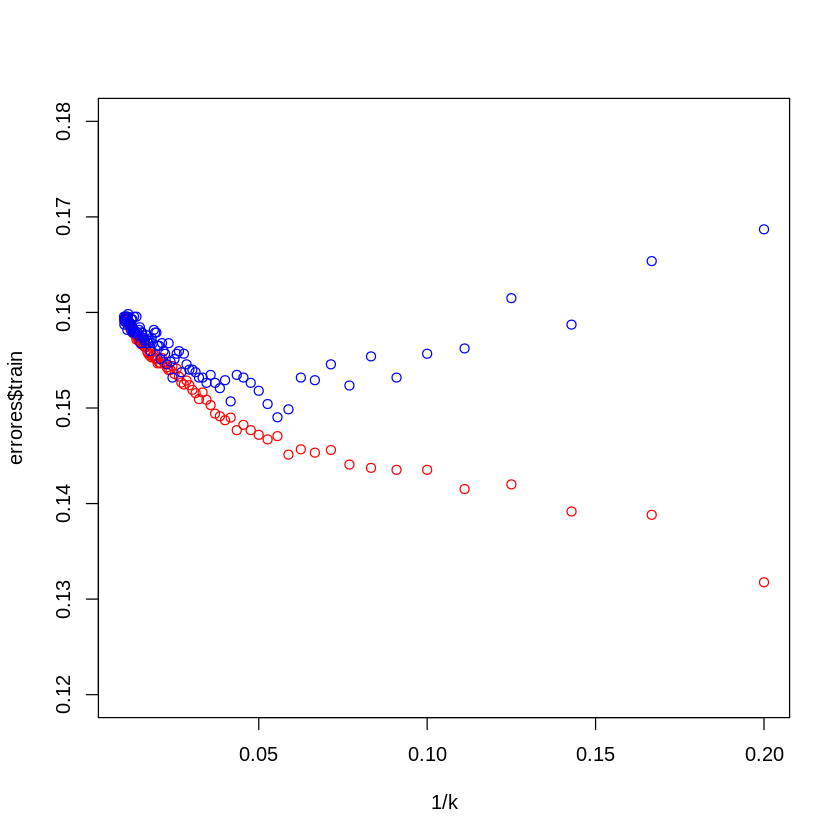

In [ ]:
cv_train_test_comp <- function (df, kfold, kvec){
  rows=dim(df)[1] %/% kfold
  indices=seq(1, dim(df)[1], by=1) # obtengo los indices de mi df
  shuffled_indices=sample(indices, replace=FALSE) # hago una mezcla de indices
  errores_k_test <- c()
  errores_k_train <- c()
  for (k in 1:kfold){
    test_indices=shuffled_indices[(1+(k-1)*rows):(k*rows)] # me quedo con los indices que seran utilizados para el test
    train_indices=shuffled_indices[which(!shuffled_indices %in% test_indices)]
    df_train <- df[train_indices,]
    df_test <- df[test_indices,]
    train.X <- df_train[,1:7]
    train.vector = df_train[,"content_rating"]
    test.X <- df_test[,1:7]
    knn.pred.test <- knn (train.X, test.X, train.vector , k = kvec)
    knn.pred.train <- knn (train.X, train.X, train.vector , k = kvec)

    df_test$clasificacion = knn.pred.test
    df_train$clasificacion = knn.pred.train
    errores_k_test <- c(errores_k_test,error_clasif(df_test))
    errores_k_train <- c(errores_k_train,error_clasif(df_train))
  }
  return (list(test=errores_k_test, train=errores_k_train))
}

grafico_error_kvecinos_paq_mod <- function (df, kfold, maxvecinos){
  # hace el cross-validation para cada kvec
  # plotea el ecme vs Kvecinos
  errores_test <- c()
  errores_train <- c()
  for (kvec in 5:maxvecinos){
    cv_res=cv_train_test_comp(df, 5, kvec)
    errores_test=c(errores_test, mean(cv_res$test))
    errores_train=c(errores_train,mean(cv_res$train))
  }
  return (list(test=errores_test, train=errores_train))
}


corrida_knn_mod <- function (df){
    maximo_vecinos <- 100
    kfold <- 5
    df= df[,c("profit","budget","gross", "imdb_score", "duration","movie_facebook_likes", "cast_total_facebook_likes","content_rating")]
    df_def=scale(df[,c("profit","budget","gross", "imdb_score", "duration","movie_facebook_likes", "cast_total_facebook_likes")])
    df_def=cbind(df_def, df["content_rating"])
    colnames(df_def)[8]="content_rating"
    errores <- grafico_error_kvecinos_paq_mod(df_def, 5, maximo_vecinos)
    # Grafico
    k<-5:maximo_vecinos
    plot(1/k, errores$train, col="red", ylim=c(0.12, 0.18))
    points(1/k, errores$test, col ="blue")
}

corrida_knn_mod(df_PG_13y17)

## Curvas ROC para variables

Una curva ROC representa TPR vs.  FPR en diferentes umbrales declasificaci ́on.

¿Con que umbral nos quedamos?
Depende cada problema.
Se suele elegir mediante el Indice de Youden que corresponde al maximo de
(sensibilidad+especificidad−1)

https://towardsdatascience.com/multiclass-classification-evaluation-with-roc-curves-and-roc-auc-294fd4617e3a

### ROC para modelos logisticos

In [ ]:
install.packages("ROCR")
library(ROCR)

corrida_roc <- function (df){
    df <- dplyr::select_if(df, is.numeric)
    # df
    dima = dim(df)
    grupo.train = sample(c(0 ,1) ,dima[1],replace= TRUE, prob=c( 0.10 , 0.90))
    indices<- 1:dima[1]
    indices.train<- (indices[grupo.train ==1])

    datos.train<-df[indices.train,]
    datos.test<-df[-indices.train,]

    explicatorias <- names(df)
    auces <- c()

    for (m in 1:length(explicatorias)){

    p <- as.formula(paste("content_rating", explicatorias[m], sep = " ~ "))

    salida.train <- glm(p, data=datos.train, family=binomial)
    predicciones<-predict.glm( salida.train , datos.test , type="response")

    predict.rocr<- prediction( predicciones , datos.test$content_rating)
    pref.rocr<- performance(predict.rocr ,"tpr", "fpr")
    auc.cui<- as.numeric( performance (predict.rocr , "auc")@y.values)
    auces <- c(auces, auc.cui)
    plot( pref.rocr , colorize=TRUE, type="l" , main=paste ( explicatorias[m]," AUC=",round(auc.cui,2)) )
    abline(a=0,b=1)
    }
    tabla_auc<-data.frame(explicatorias,auces)
    colnames(tabla_auc)<-c("Explicatorias", "AUC")
    # tabla_auc[order(tabla_auc$AUC),]
    tabla_auc <- tabla_auc[order(-tabla_auc$AUC),]
    # sort(x, decreasing = FALSE, na.last = TRUE)
    tabla_auc
}

# df_PG_17

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



profit                    budget                     gross 
                        0                         0                         0 
               imdb_score                  duration      movie_facebook_likes 
                        0                         0                         0 
cast_total_facebook_likes            content_rating 
                        0                         0

[1] " "


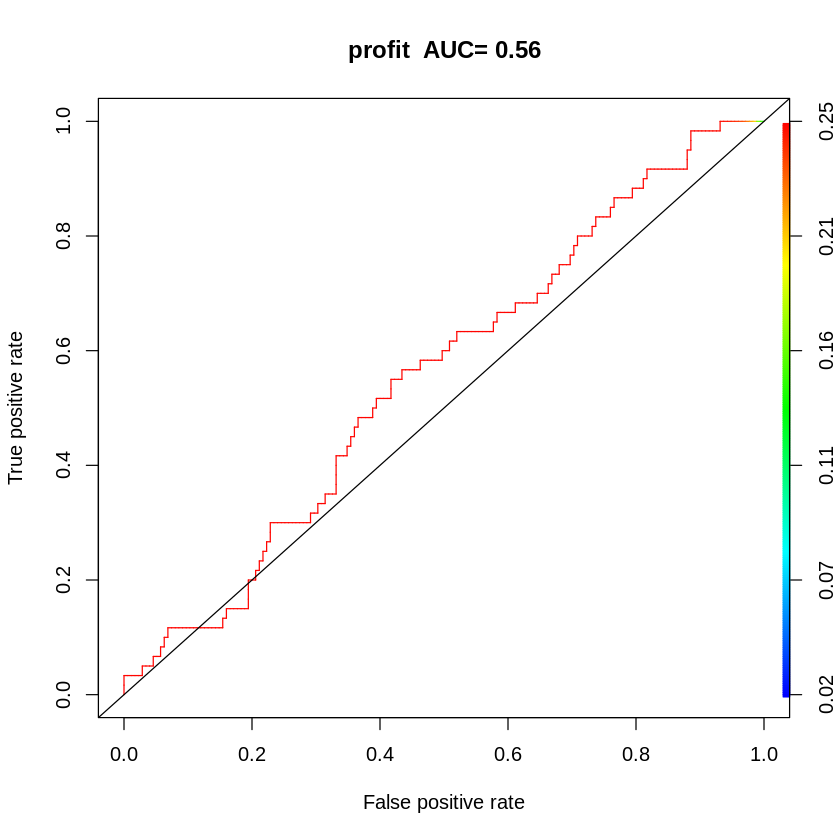

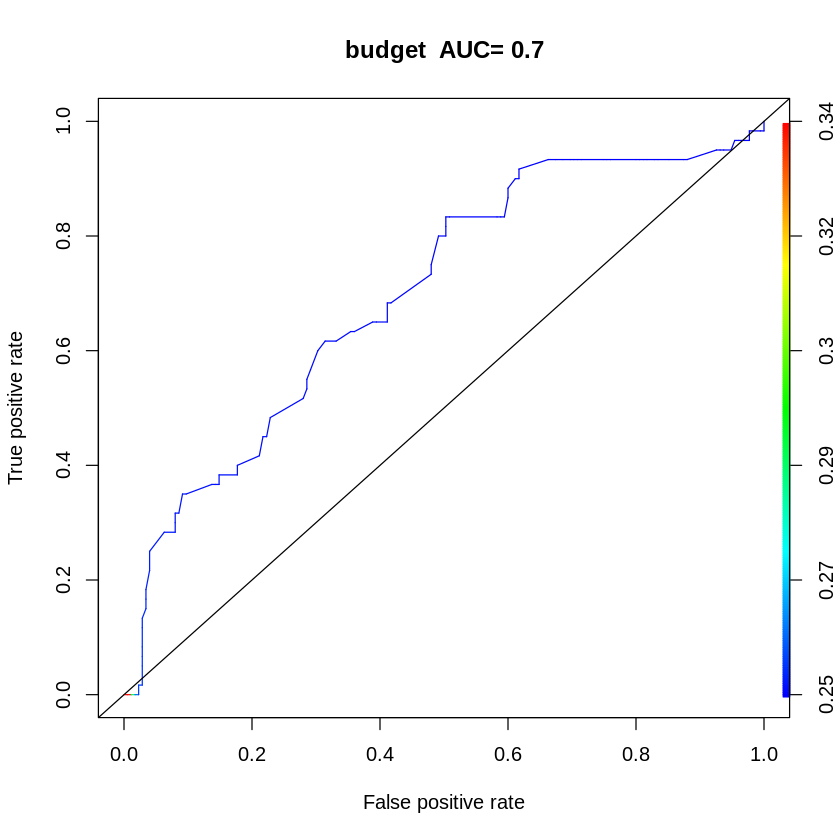

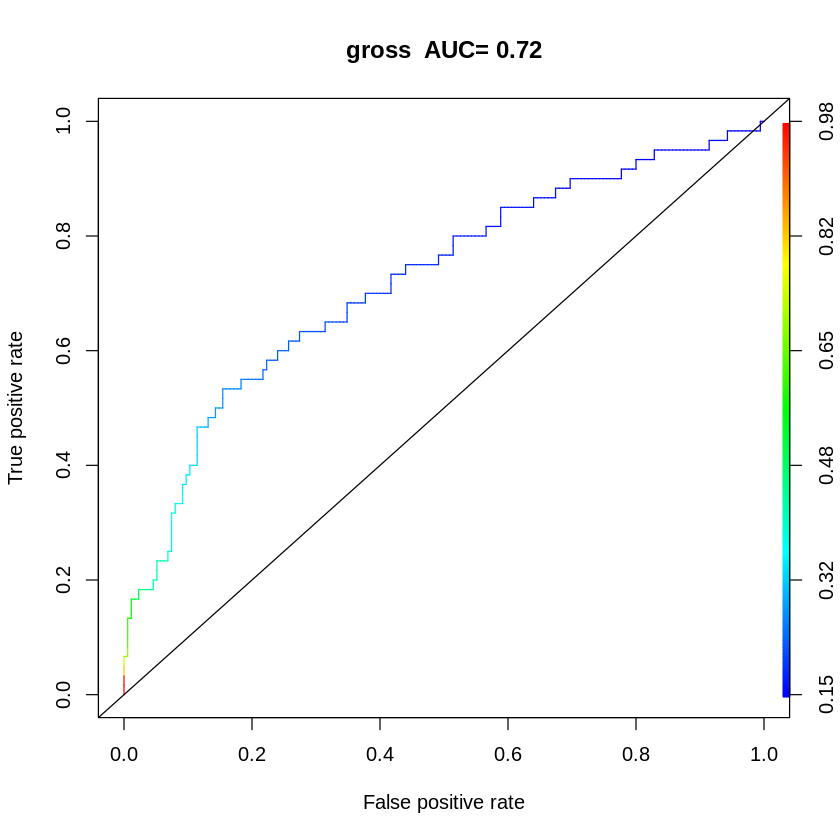

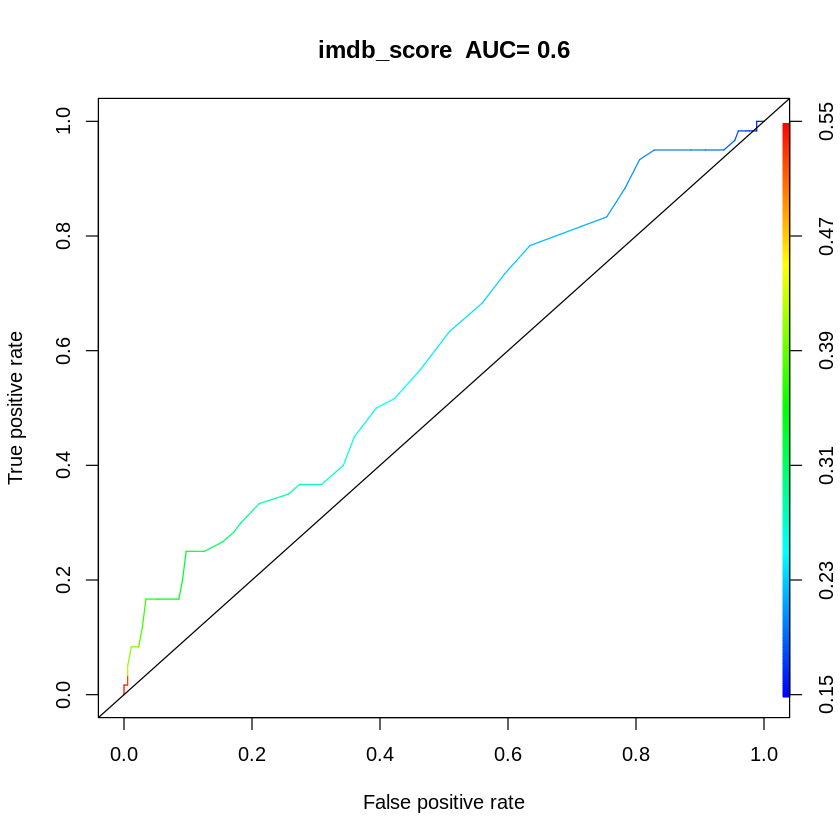

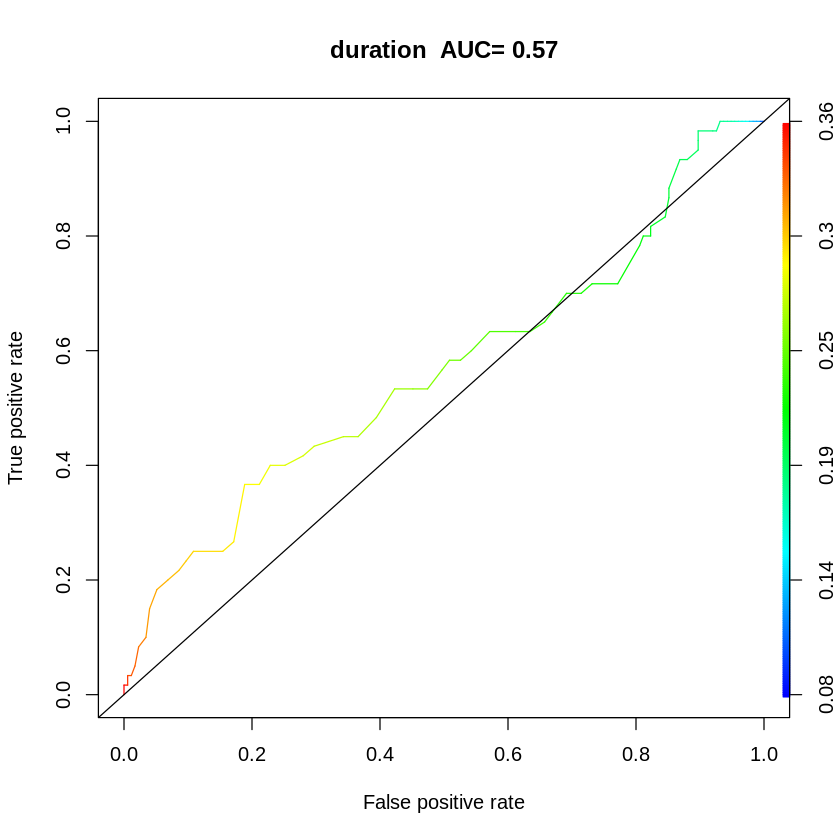

Warning message in model.matrix.default(mt, mf, contrasts):
“the response appeared on the right-hand side and was dropped”
Warning message in model.matrix.default(mt, mf, contrasts):
“problem with term 1 in model.matrix: no columns are assigned”


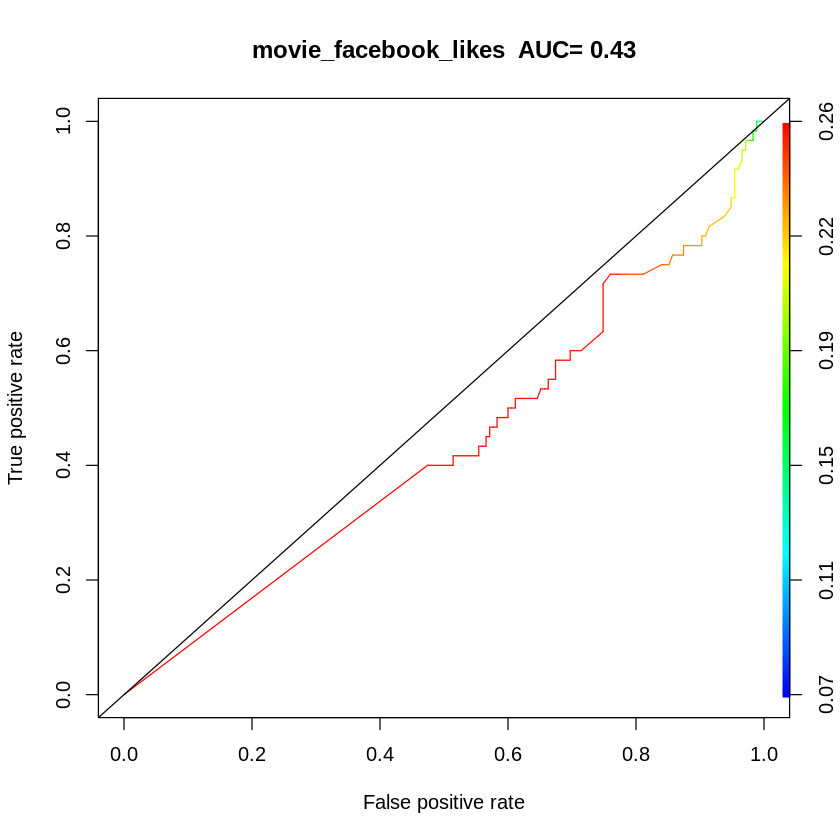

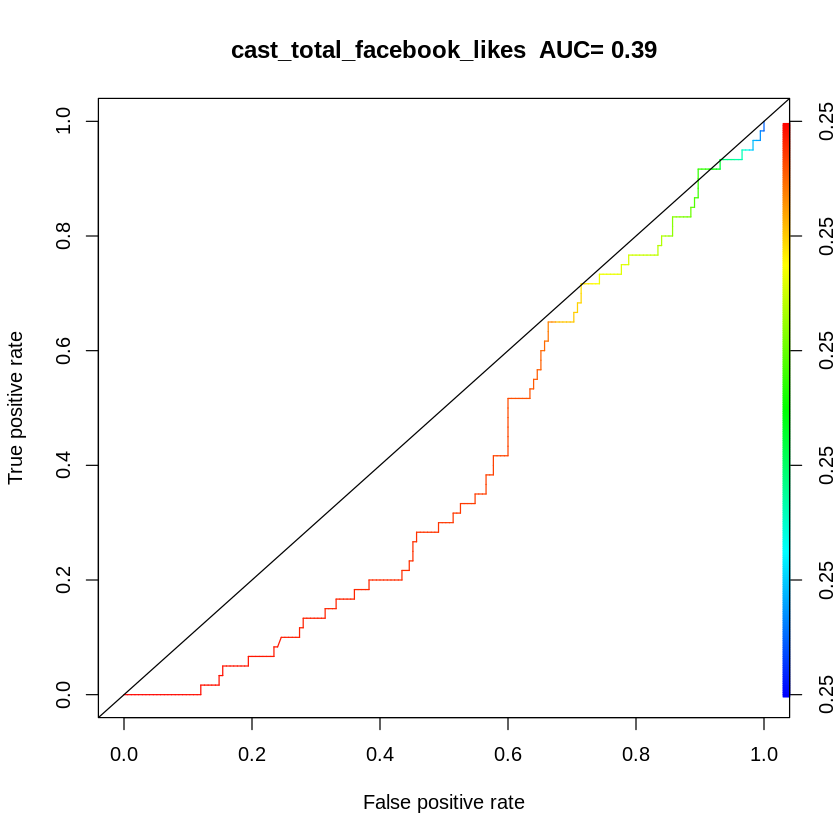

,Explicatorias,AUC
,<chr>,<dbl>
3,gross,0.7220952
2,budget,0.6996667
4,imdb_score,0.5969524
5,duration,0.5660000
1,profit,0.5567619
8,content_rating,0.5000000
6,movie_facebook_likes,0.4345238
7,cast_total_facebook_likes,0.3945238


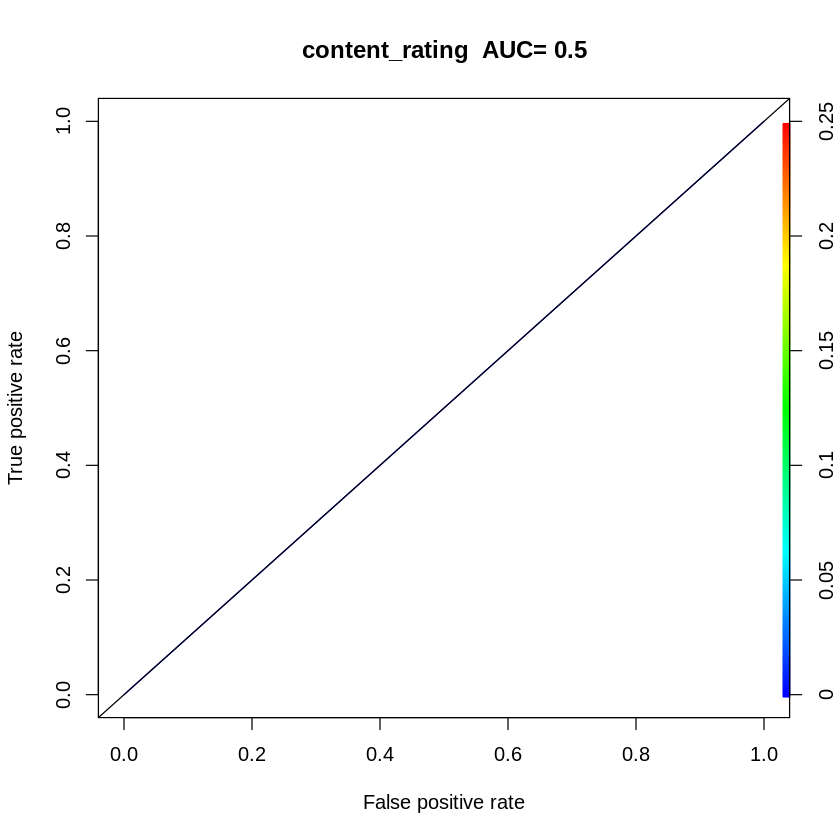

In [ ]:
# 1) DATAFRAME df_PG_17 donde queda PG vs R
df_PG_17 <- df_def[df_def$content_rating %in% c("PG","R"),] # Hago binaria la variable respuesta (VR)
df_PG_17$content_rating = ifelse(df_PG_17$content_rating=="PG",1,0) # Hago entre 0 y 1 la VR
#print('¿Que variables tienen valores vacios?')
#df_PG_17<- df_PG_17[!is.na(df_PG_17$facenumber_in_poster), ]
#df_PG_17 <- subset(df_PG_17, select = -aspect_ratio)

colSums(sapply(df_PG_17, is.na))
print(' ')

corrida_roc(df_PG_17)

profit                    budget                     gross 
                        0                         0                         0 
               imdb_score                  duration      movie_facebook_likes 
                        0                         0                         0 
cast_total_facebook_likes            content_rating 
                        0                         0

[1] " "


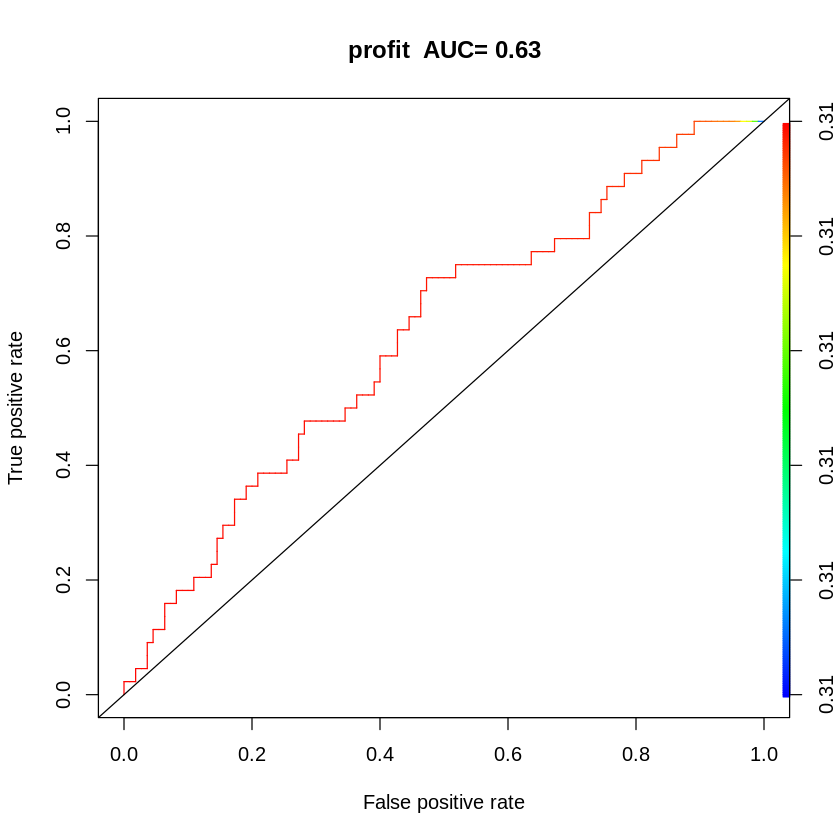

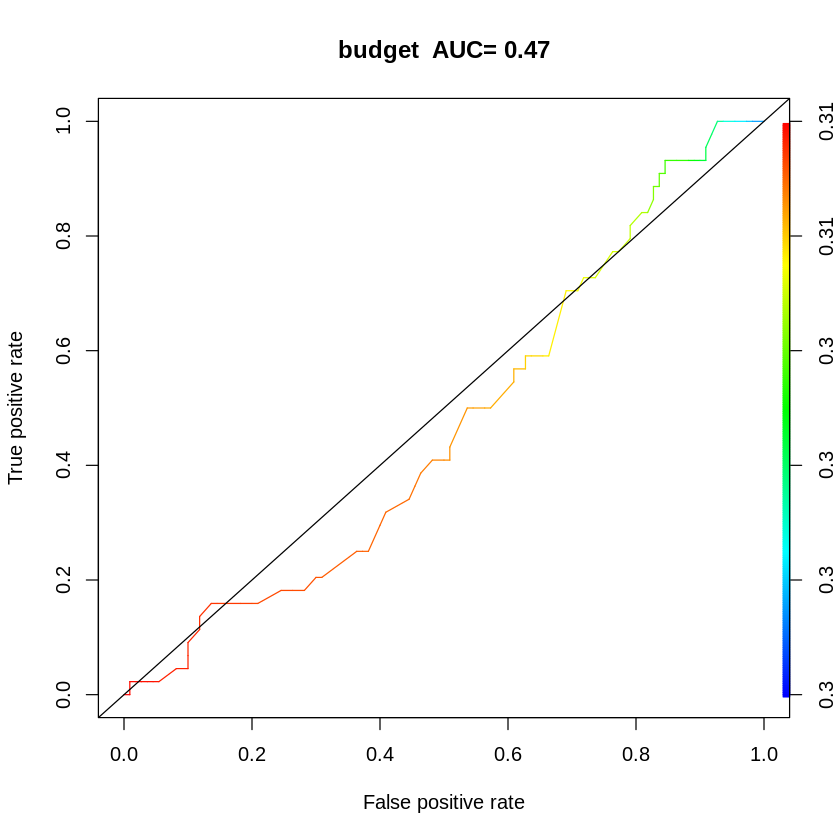

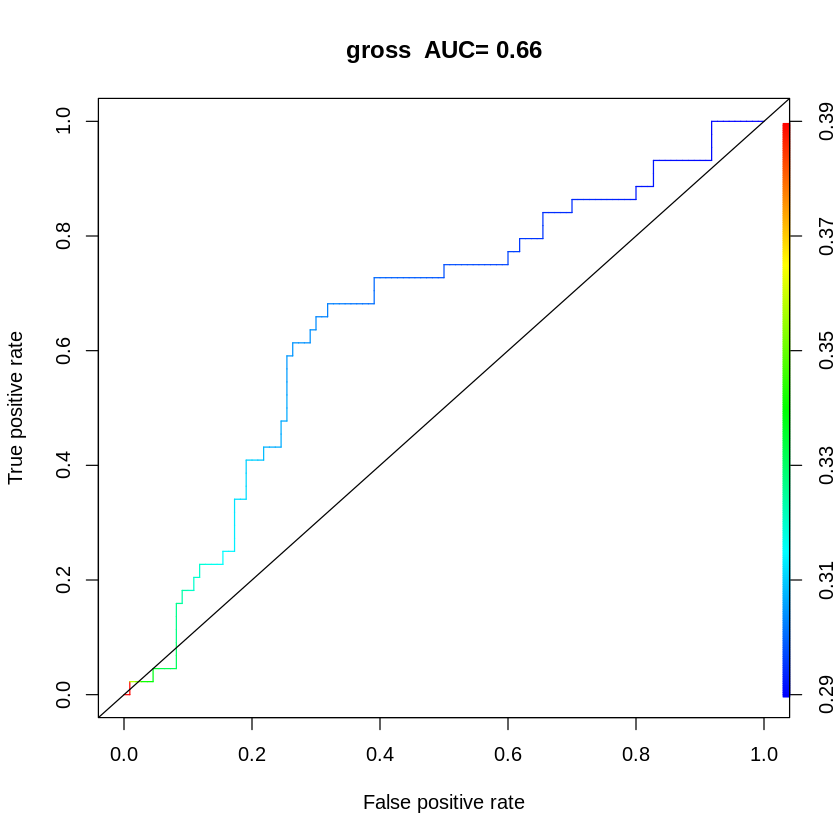

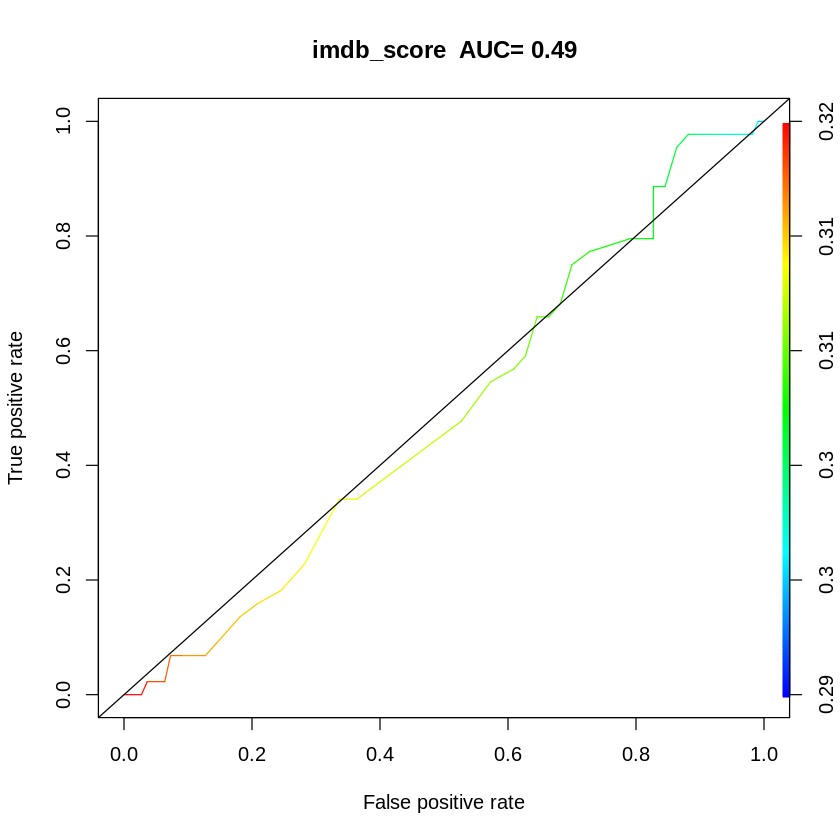

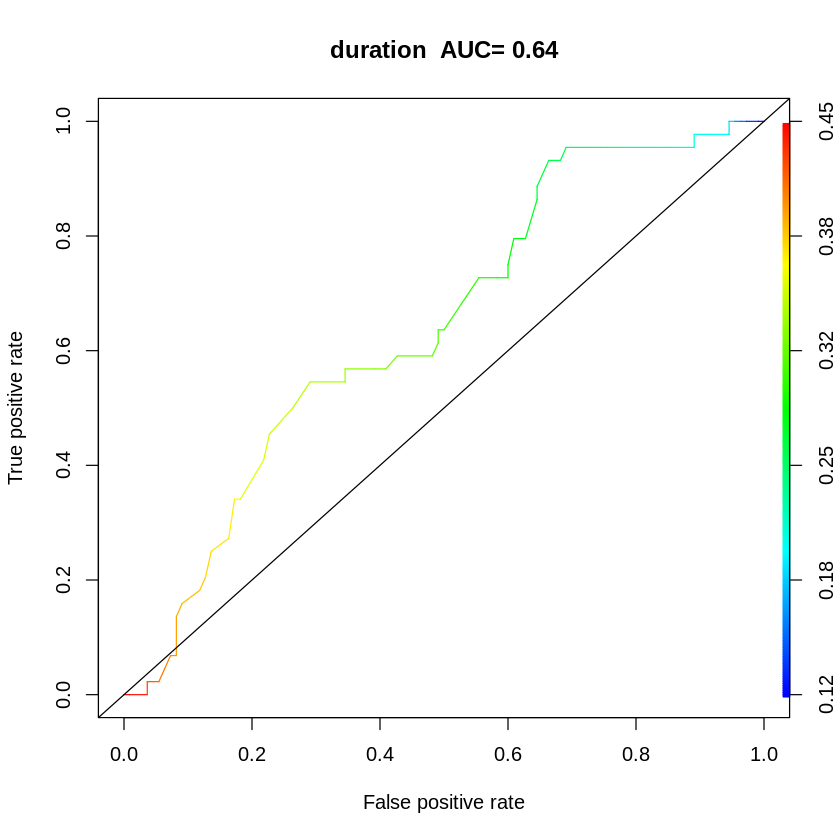

Warning message in model.matrix.default(mt, mf, contrasts):
“the response appeared on the right-hand side and was dropped”
Warning message in model.matrix.default(mt, mf, contrasts):
“problem with term 1 in model.matrix: no columns are assigned”


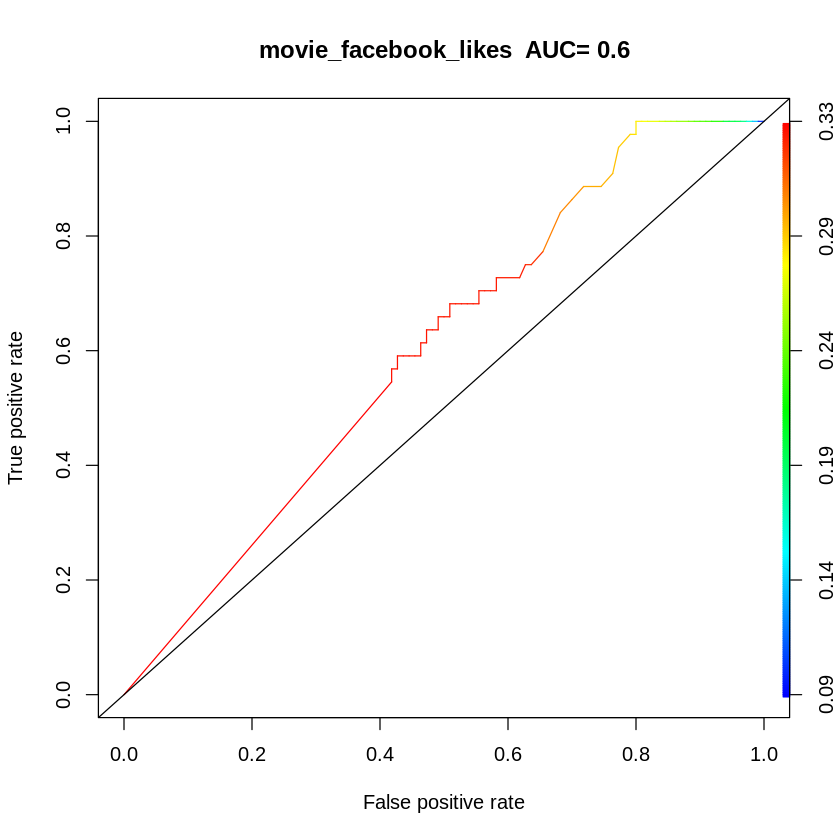

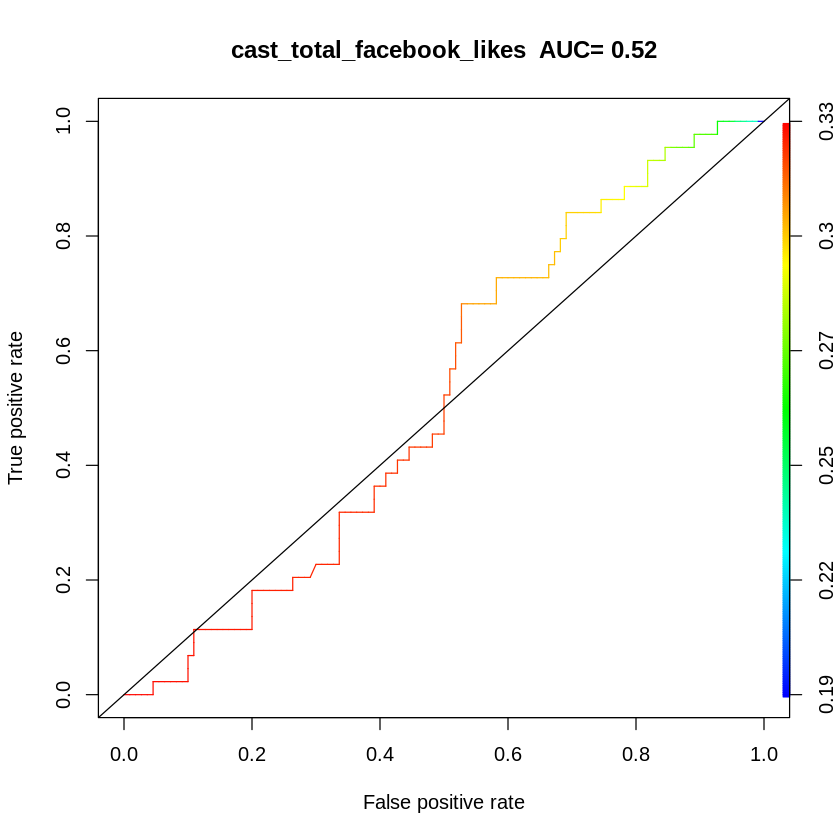

,Explicatorias,AUC
,<chr>,<dbl>
3,gross,0.6574380
5,duration,0.6414256
1,profit,0.6266529
6,movie_facebook_likes,0.6026860
7,cast_total_facebook_likes,0.5217975
8,content_rating,0.5000000
4,imdb_score,0.4882231
2,budget,0.4690083


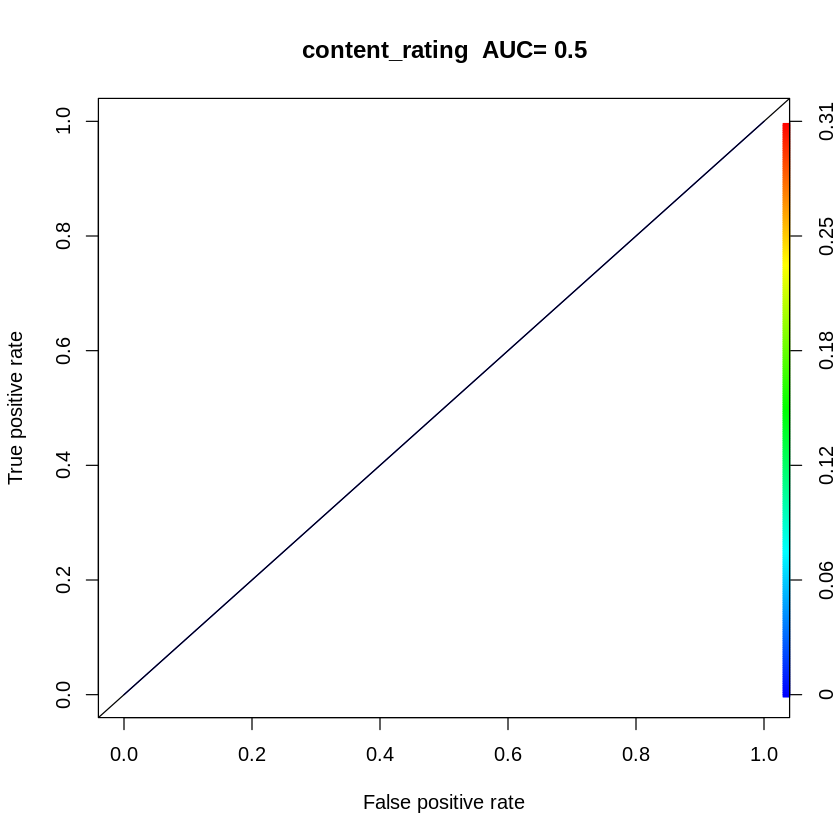

In [ ]:
# 2) DATAFRAME donde queda PG vs PG-13
df_PG_13 <- df_def[df_def$content_rating %in% c("PG","PG-13"),]
df_PG_13$content_rating = ifelse(df_PG_13$content_rating=="PG",1,0) # Hago entre 0 y 1 la VR
#print('¿Que variables tienen valores vacios?')
#df_PG_13<- df_PG_13[!is.na(df_PG_13$facenumber_in_poster), ]
#df_PG_13 <- subset(df_PG_13, select = -aspect_ratio)

colSums(sapply(df_PG_13, is.na))
print(' ')

corrida_roc(df_PG_13)

profit                    budget                     gross 
                        0                         0                         0 
               imdb_score                  duration      movie_facebook_likes 
                        0                         0                         0 
cast_total_facebook_likes            content_rating 
                        0                         0

[1] " "


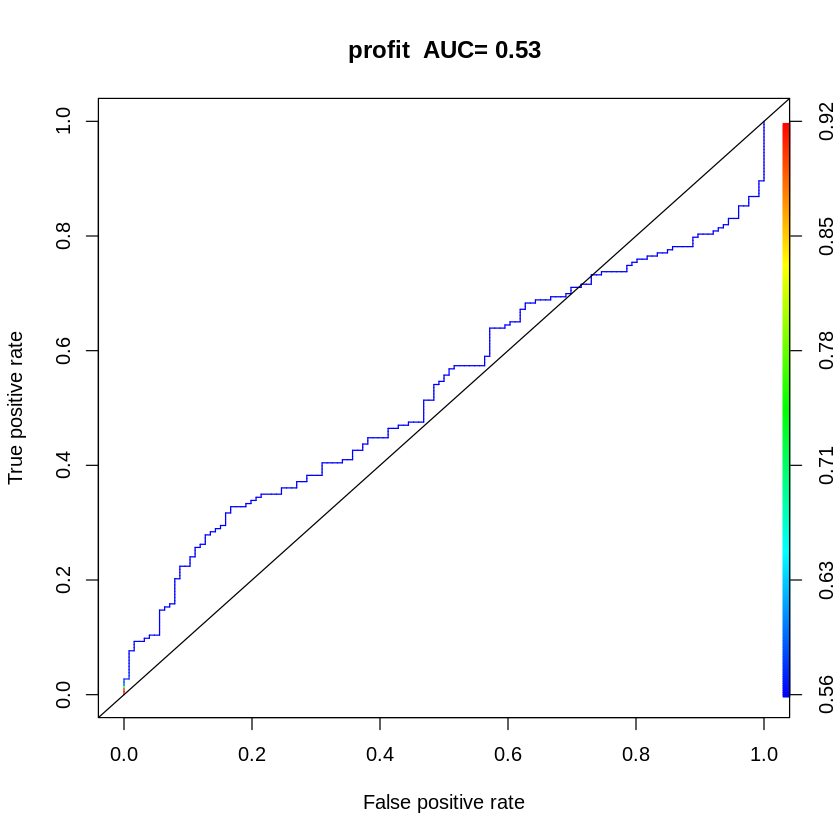

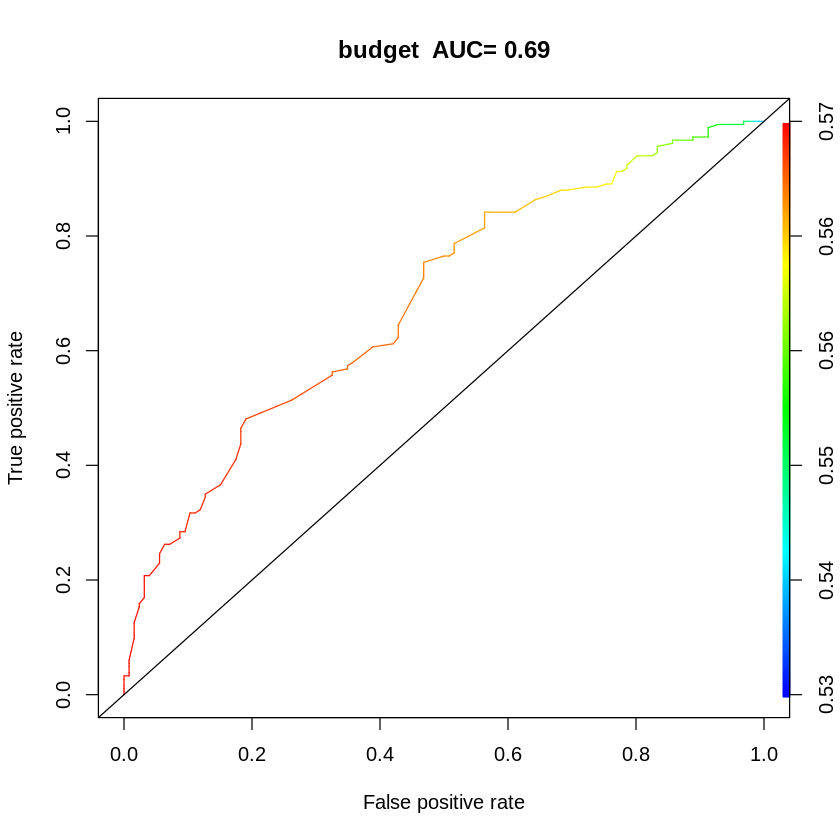

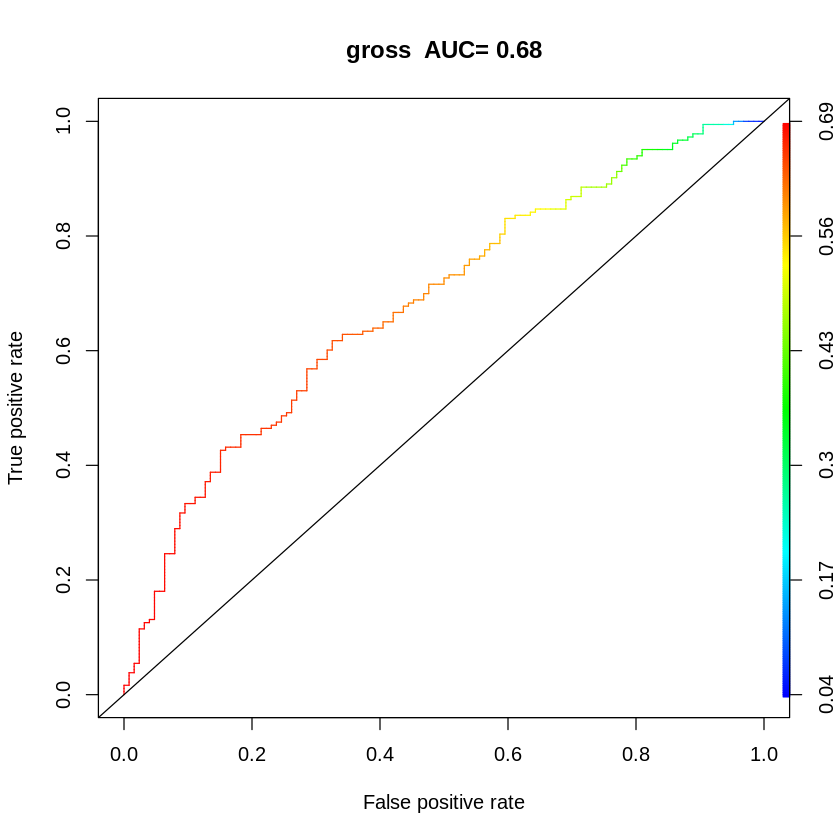

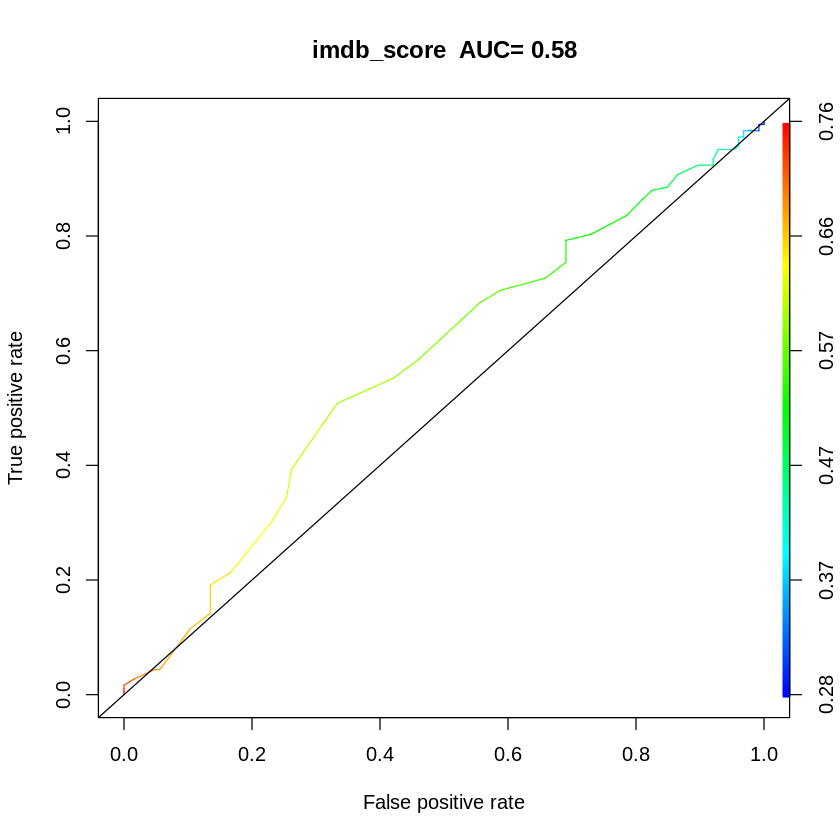

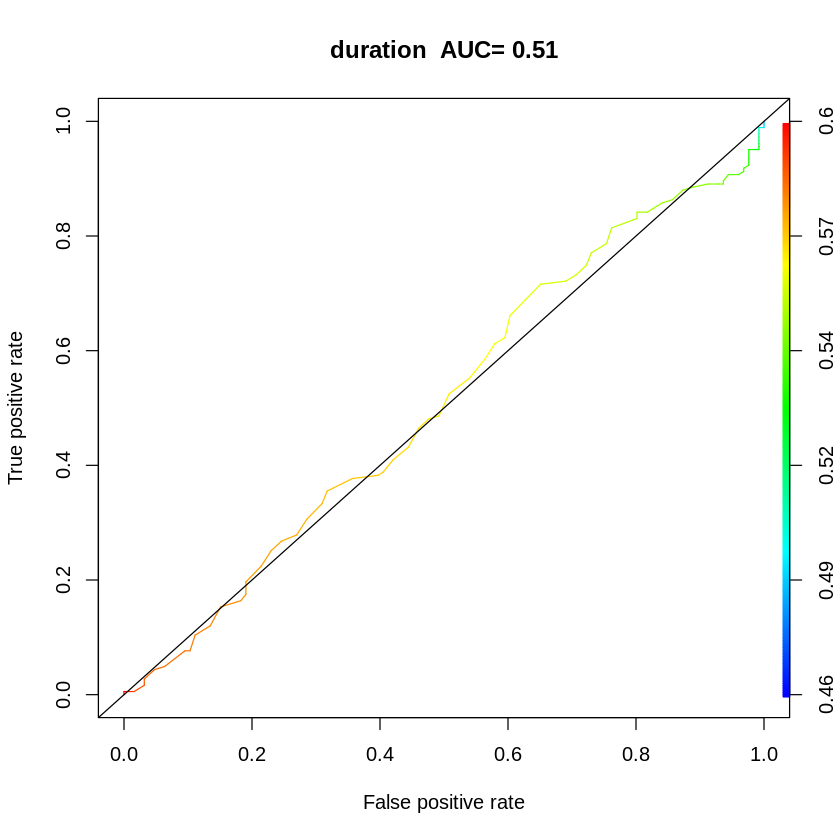

Warning message in model.matrix.default(mt, mf, contrasts):
“the response appeared on the right-hand side and was dropped”
Warning message in model.matrix.default(mt, mf, contrasts):
“problem with term 1 in model.matrix: no columns are assigned”


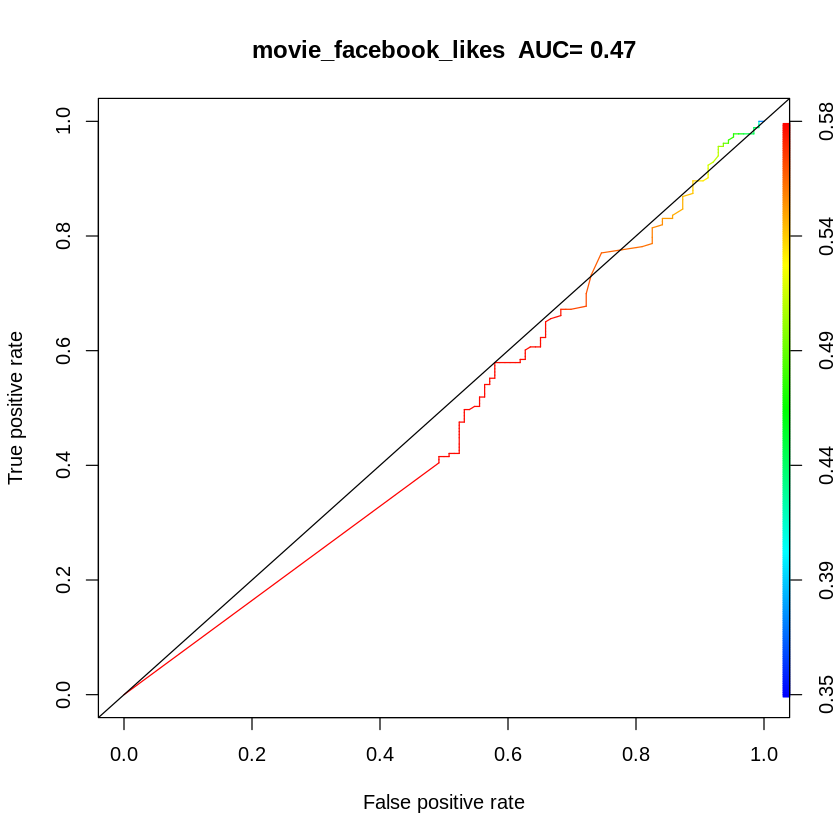

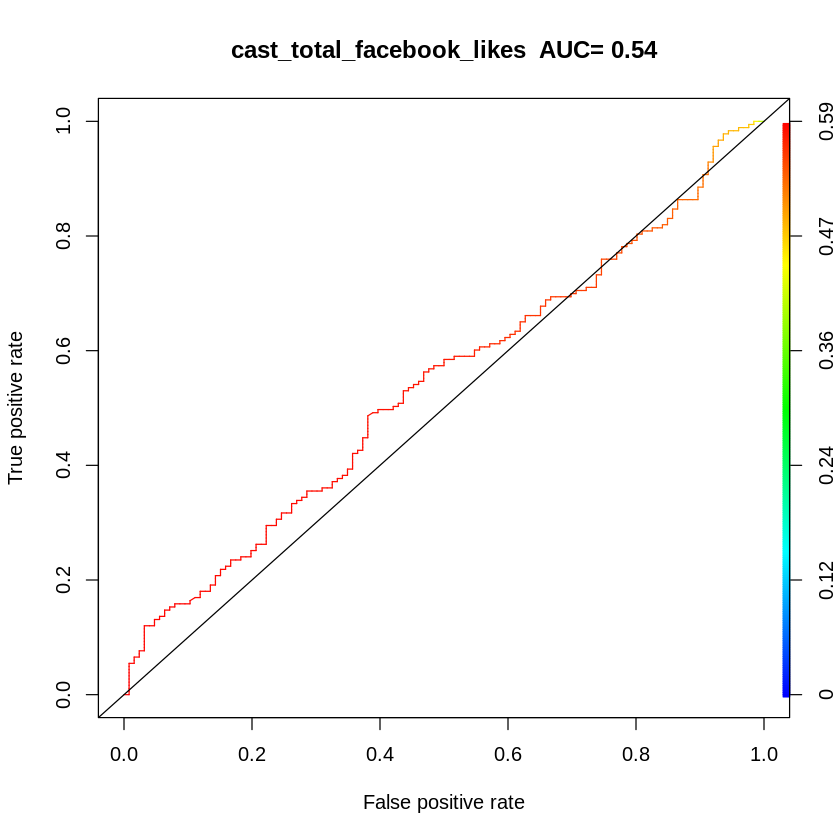

,Explicatorias,AUC
,<chr>,<dbl>
2,budget,0.6880909
3,gross,0.6824529
4,imdb_score,0.5753101
7,cast_total_facebook_likes,0.5388585
1,profit,0.5300546
5,duration,0.5094327
8,content_rating,0.5000000
6,movie_facebook_likes,0.4691430


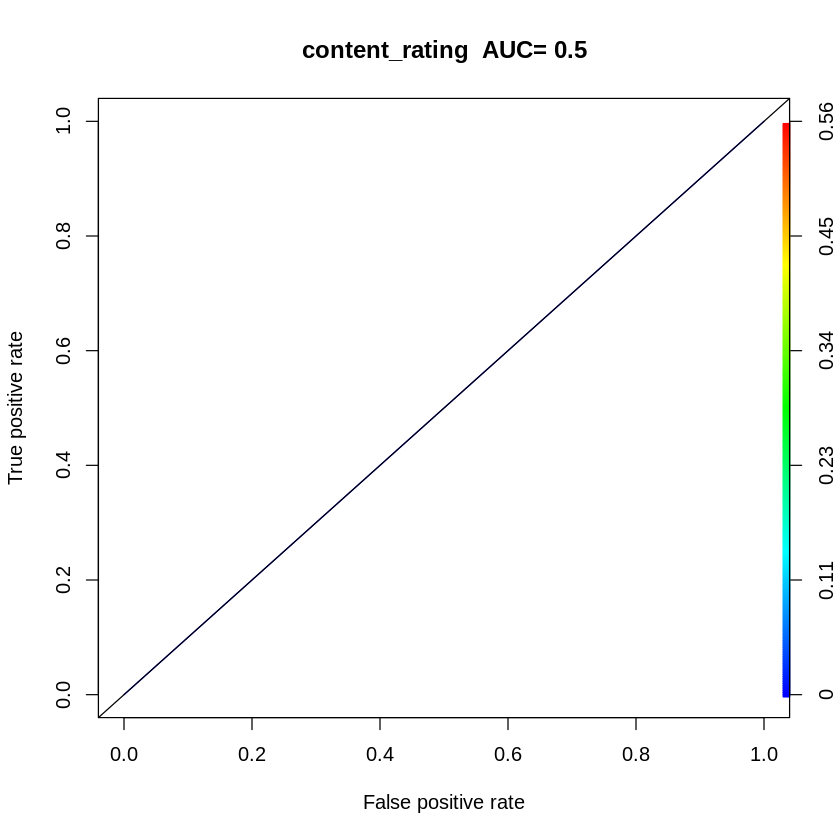

In [ ]:
# 3) DATAFRAME donde queda PG-13 vs R
df_13_R <- df_def[df_def$content_rating %in% c("R","PG-13"),]
df_13_R$content_rating = ifelse(df_13_R$content_rating=="R",1,0) # Hago entre 0 y 1 la VR
#print('¿Que variables tienen valores vacios?')
#df_13_R<- df_13_R[!is.na(df_13_R$facenumber_in_poster), ]
#df_13_R<- df_13_R[!is.na(df_13_R$num_critic_for_reviews), ]

#df_13_R <- subset(df_13_R, select = -aspect_ratio)

colSums(sapply(df_13_R, is.na))
print(' ')

corrida_roc(df_13_R)

content_rating
  PG    R 
1890 1722 

profit                    budget                     gross 
                        0                         0                         0 
               imdb_score                  duration      movie_facebook_likes 
                        0                         0                         0 
cast_total_facebook_likes            content_rating 
                        0                         0

[1] " "


Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


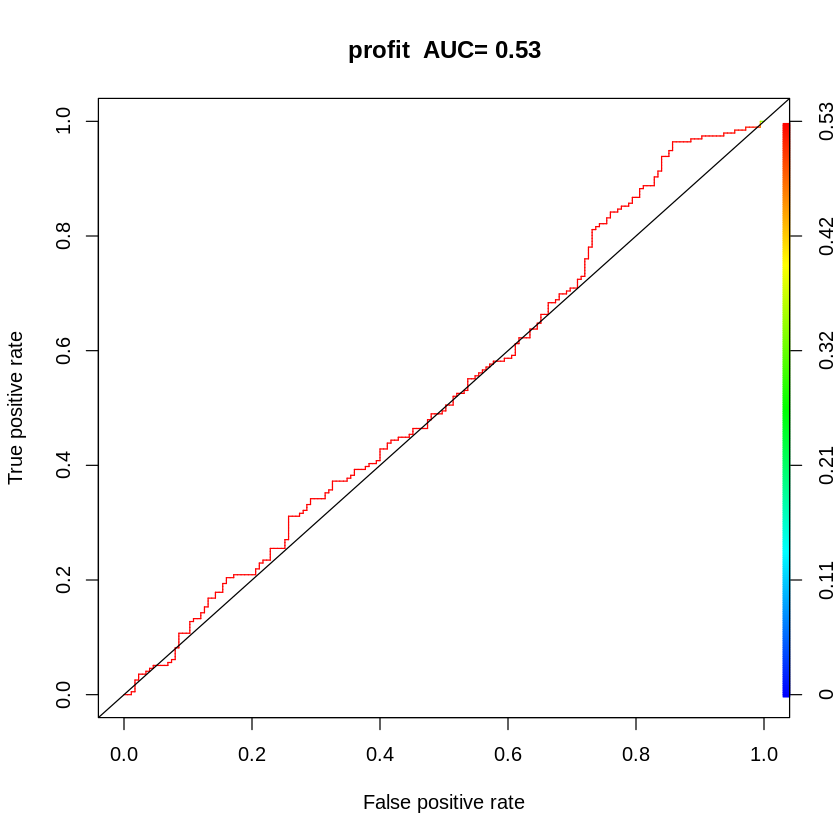

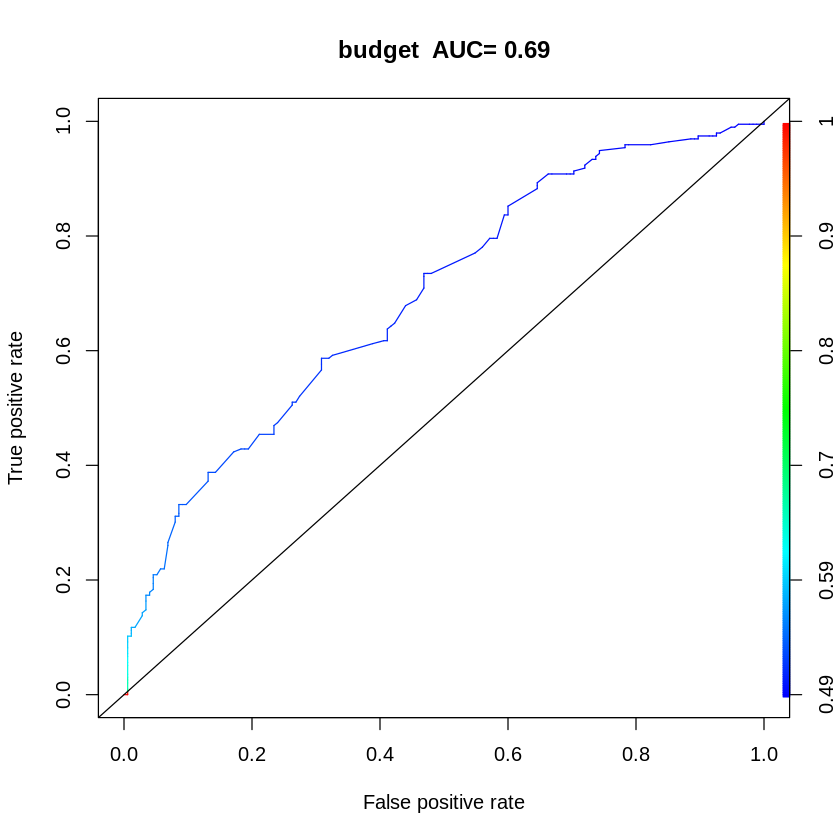

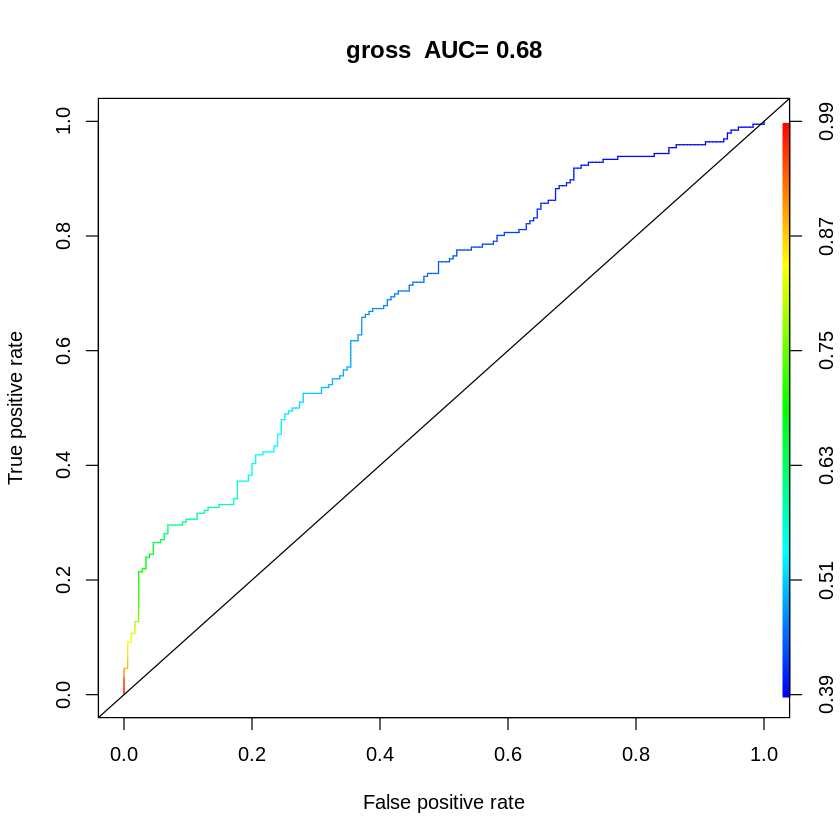

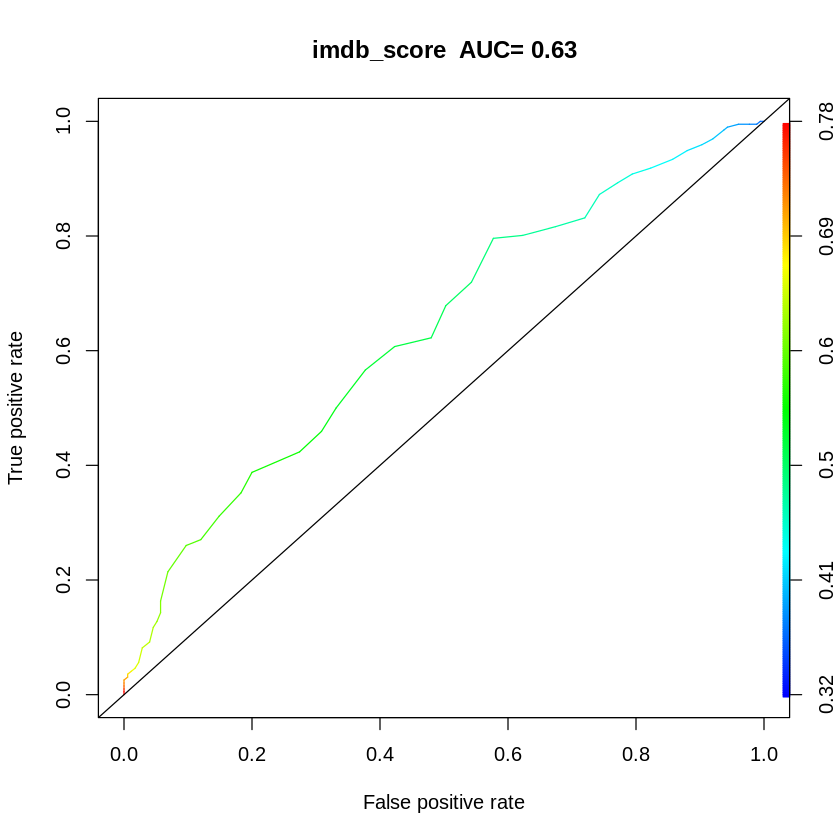

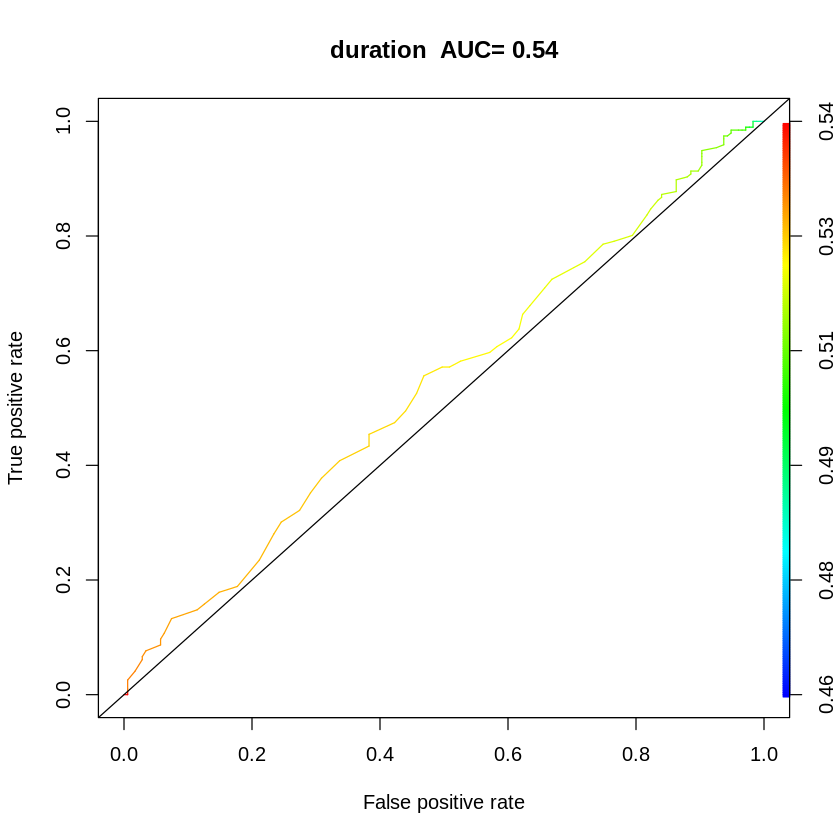

Warning message in model.matrix.default(mt, mf, contrasts):
“the response appeared on the right-hand side and was dropped”
Warning message in model.matrix.default(mt, mf, contrasts):
“problem with term 1 in model.matrix: no columns are assigned”


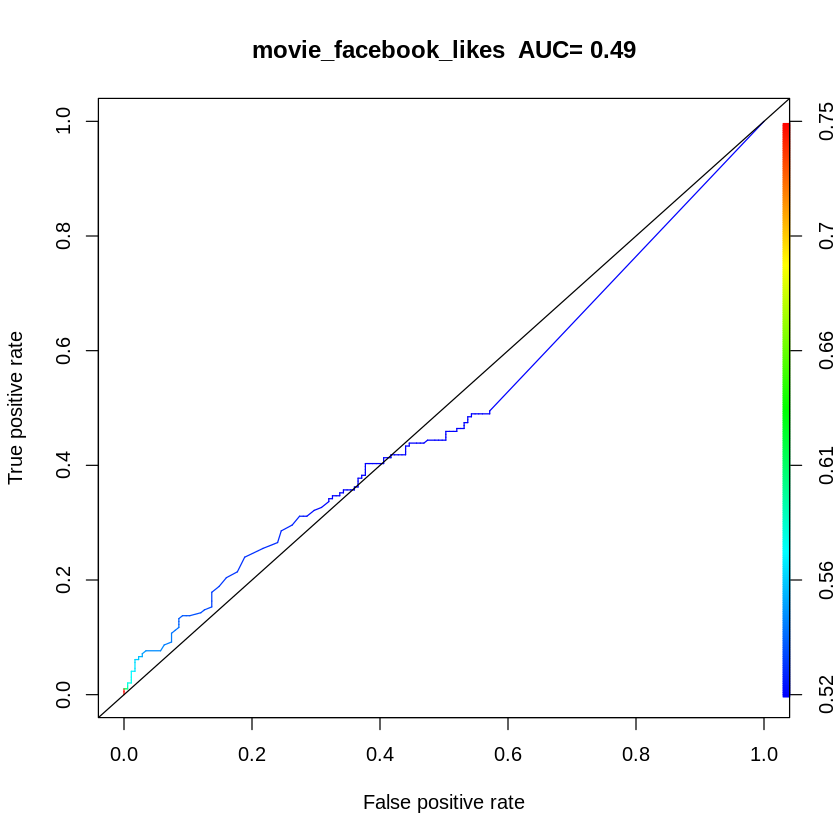

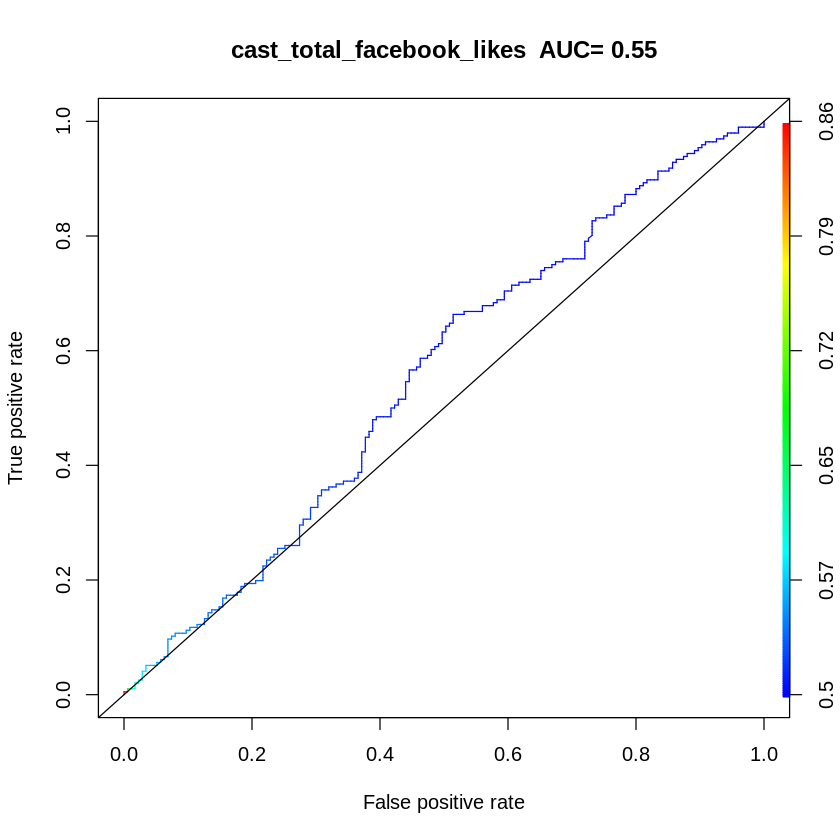

,Explicatorias,AUC
,<chr>,<dbl>
2,budget,0.6931050
3,gross,0.6825364
4,imdb_score,0.6347230
7,cast_total_facebook_likes,0.5537755
5,duration,0.5399854
1,profit,0.5261224
8,content_rating,0.5000000
6,movie_facebook_likes,0.4885860


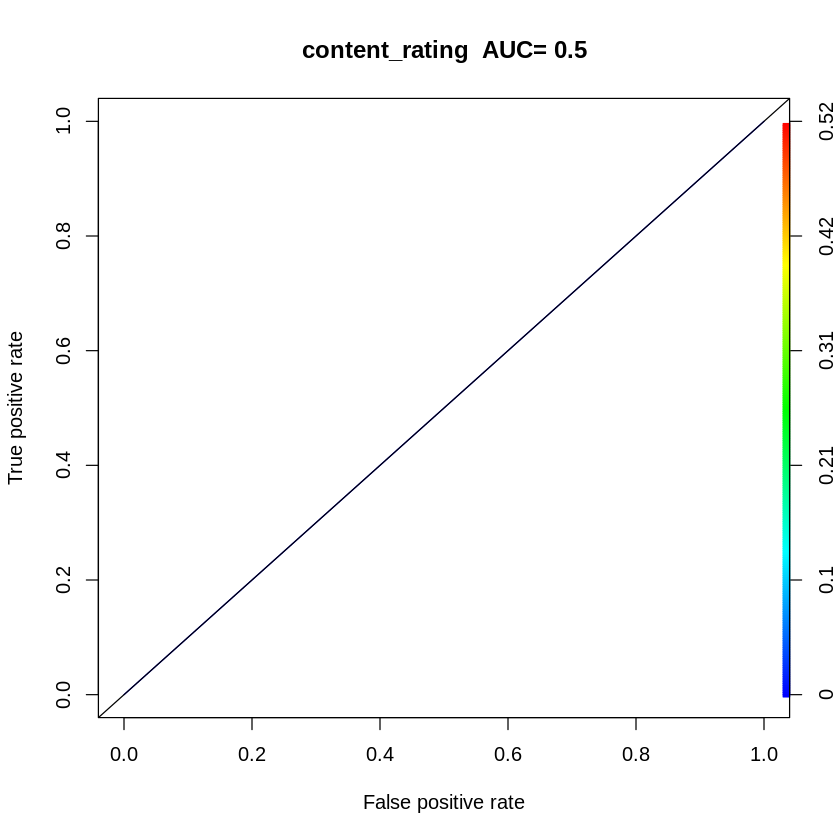

In [ ]:
# 4) DATAFRAME df_PGy13_17 donde se juntan PG y PG-13 vs R
df_PGy13_17 <- df_def[df_def$content_rating %in% c("PG","R","PG-13"),]
df_PGy13_17$content_rating[df_PGy13_17$content_rating == 'PG-13'] <- 'PG'
table(df_PGy13_17['content_rating'])

df_PGy13_17$content_rating = ifelse(df_PGy13_17$content_rating=="PG",1,0) # Hago entre 0 y 1 la VR
#print('¿Que variables tienen valores vacios?')
#df_PGy13_17<- df_PGy13_17[!is.na(df_PGy13_17$facenumber_in_poster), ]
#df_PGy13_17<- df_PGy13_17[!is.na(df_PGy13_17$num_critic_for_reviews), ]

#df_PGy13_17 <- subset(df_PGy13_17, select = -aspect_ratio)

colSums(sapply(df_PGy13_17, is.na))
print(' ')

corrida_roc(df_PGy13_17)

profit                    budget                     gross 
                        0                         0                         0 
               imdb_score                  duration      movie_facebook_likes 
                        0                         0                         0 
cast_total_facebook_likes            content_rating 
                        0                         0

[1] " "


Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


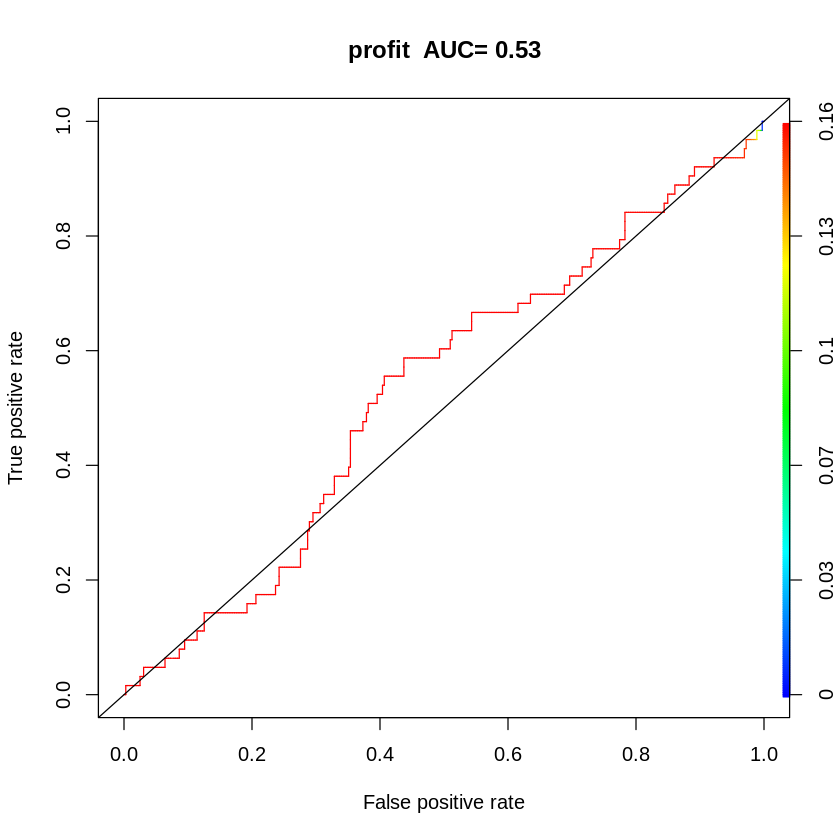

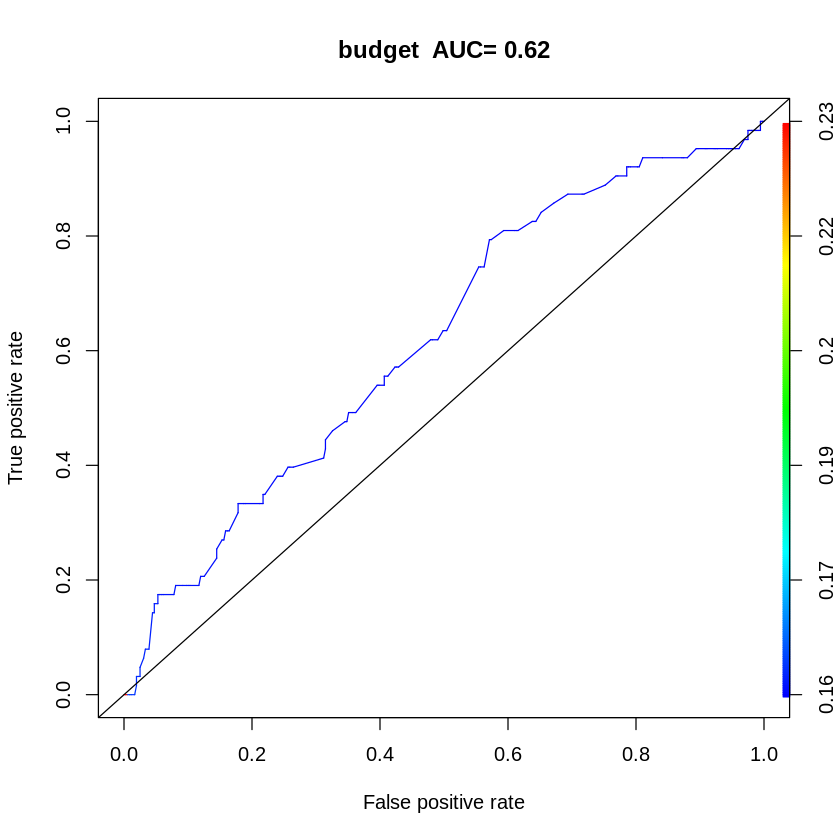

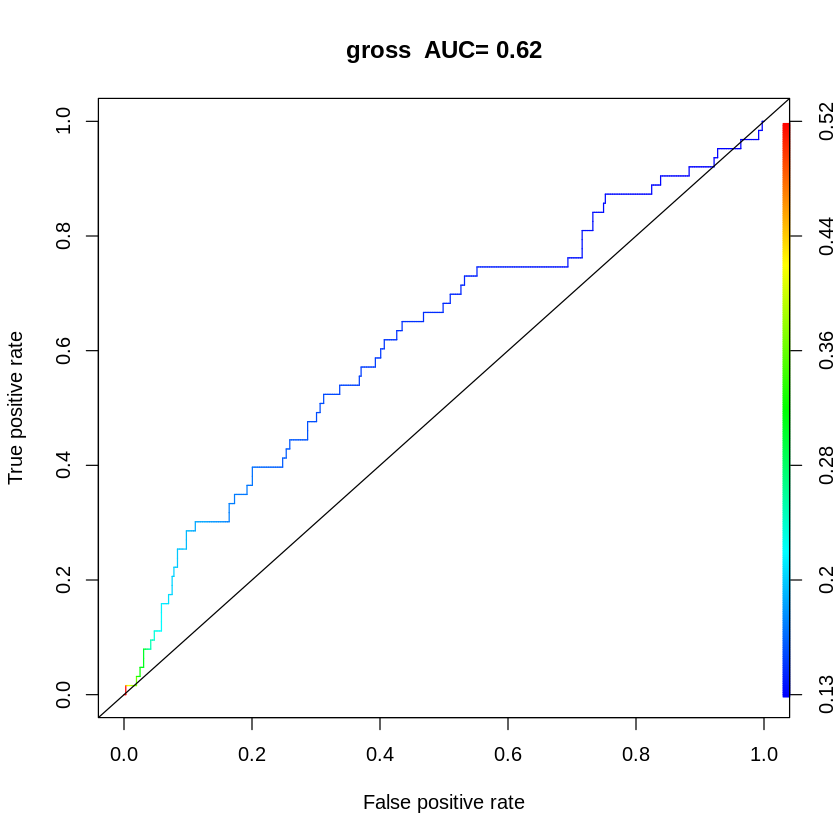

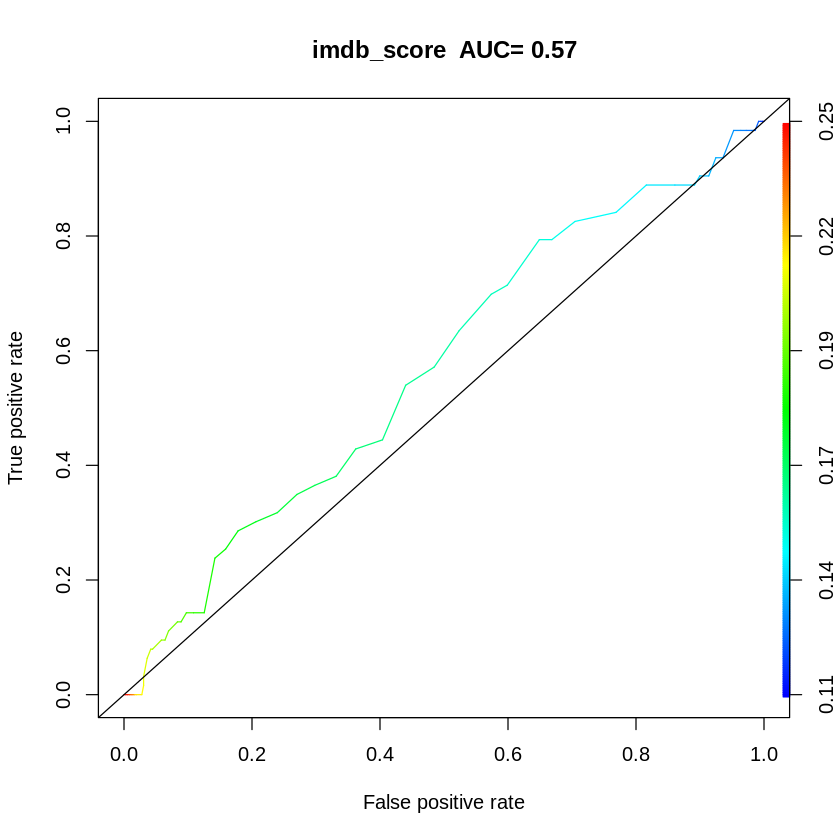

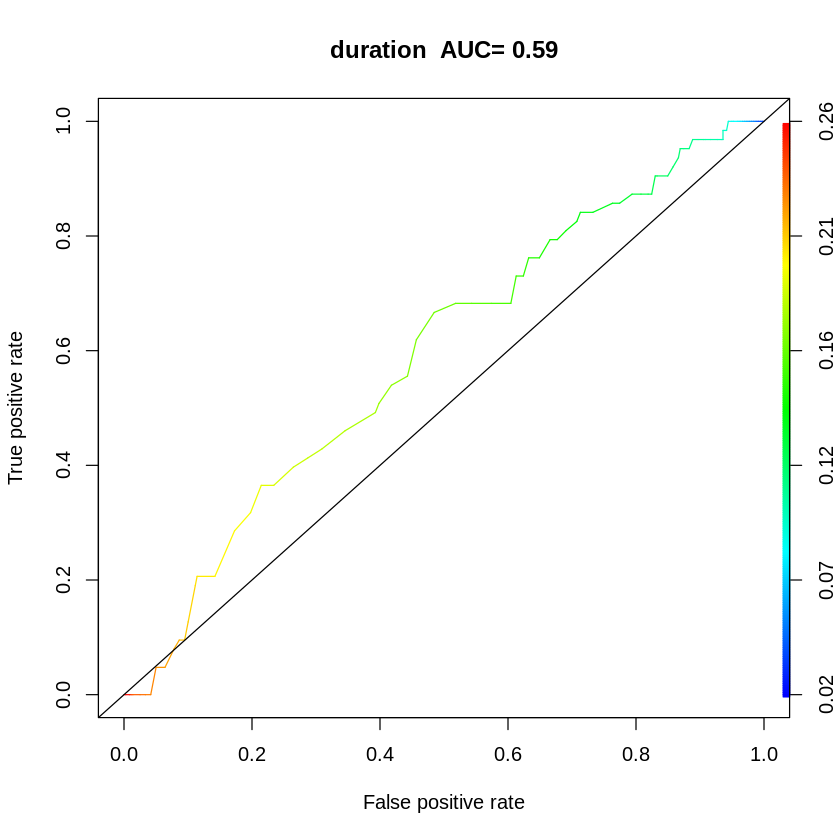

Warning message in model.matrix.default(mt, mf, contrasts):
“the response appeared on the right-hand side and was dropped”
Warning message in model.matrix.default(mt, mf, contrasts):
“problem with term 1 in model.matrix: no columns are assigned”


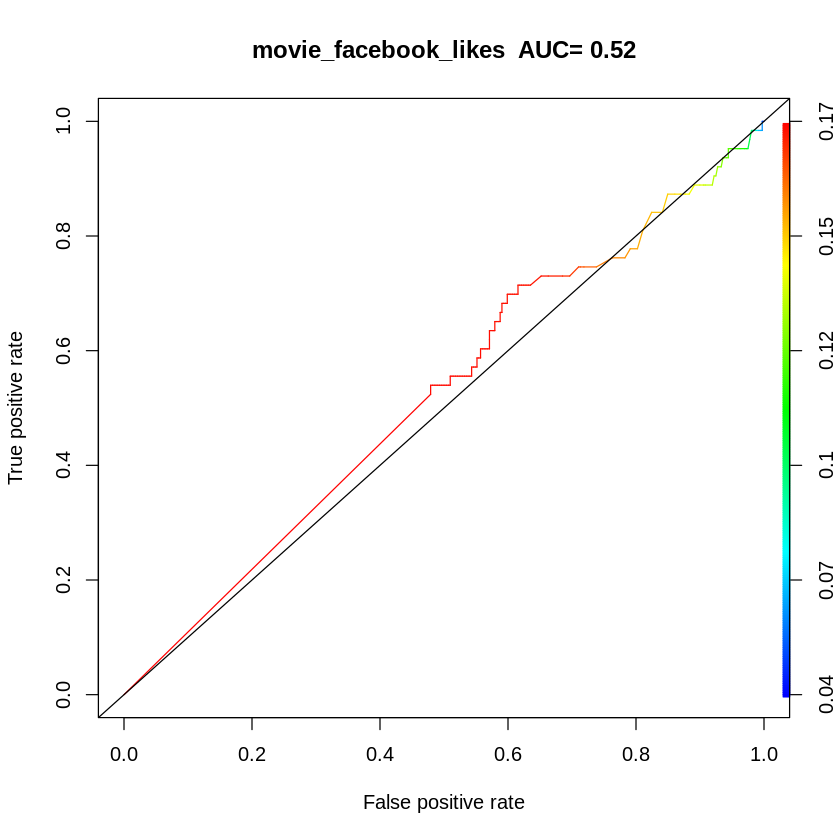

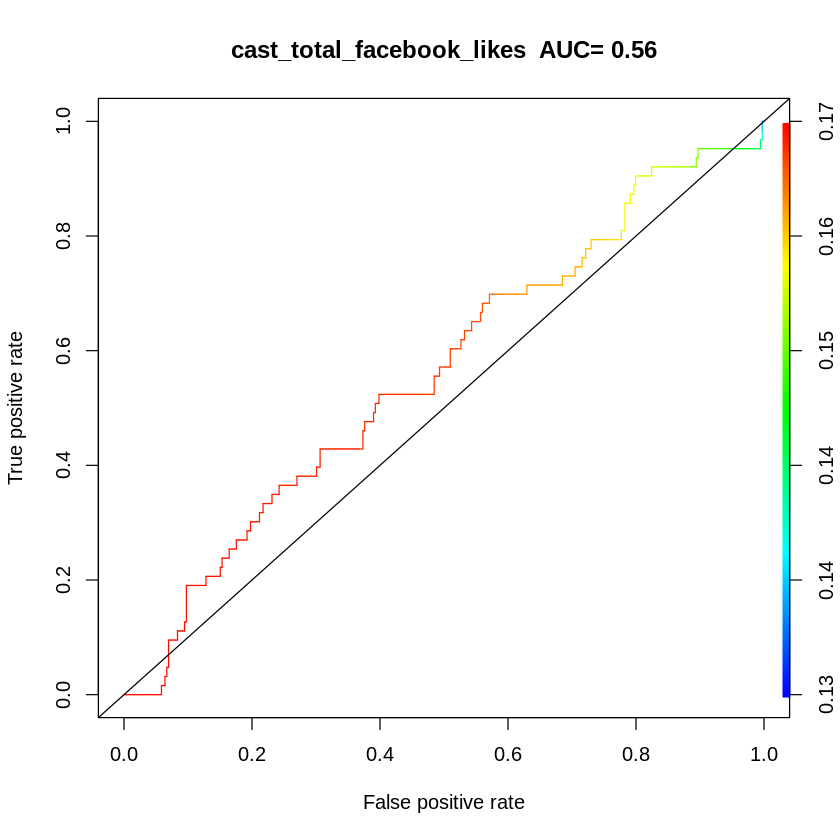

,Explicatorias,AUC
,<chr>,<dbl>
3,gross,0.6210815
2,budget,0.6187823
5,duration,0.5918336
4,imdb_score,0.5697042
7,cast_total_facebook_likes,0.5620109
1,profit,0.5322103
6,movie_facebook_likes,0.5230358
8,content_rating,0.5000000


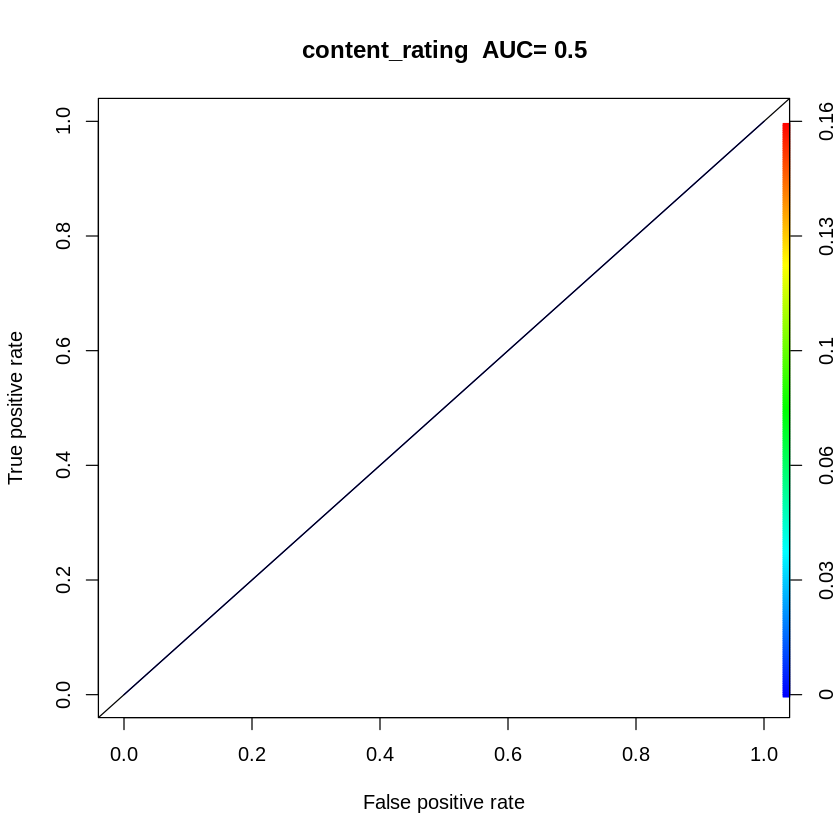

In [ ]:
# 5) DATAFRAME df_PG_13y17 donde se juntan R y PG-13 vs PG
df_PG_13y17 <- df_def[df_def$content_rating %in% c("PG","R","PG-13"),]
df_PG_13y17$content_rating[df_PG_13y17$content_rating == 'PG-13'] <- 'R'


df_PG_13y17$content_rating = ifelse(df_PG_13y17$content_rating=="PG",1,0) # Hago entre 0 y 1 la VR
#print('¿Que variables tienen valores vacios?')
#df_PG_13y17<- df_PG_13y17[!is.na(df_PG_13y17$facenumber_in_poster), ]
#df_PG_13y17<- df_PG_13y17[!is.na(df_PG_13y17$num_critic_for_reviews), ]

#df_PG_13y17 <- subset(df_PG_13y17, select = -aspect_ratio)

colSums(sapply(df_PG_13y17, is.na))
print(' ')

corrida_roc(df_PG_13y17)

## Logistica


In [ ]:
library(tidyverse)
library(nnet)
library("boot")

In [ ]:
corrida_logistica <- function (df){

    dima = dim(df)
    grupo.train = sample(c(0 ,1) ,dima[1],replace= TRUE, prob=c( 0.10 , 0.90))
    indices<- 1:dima[1]
    indices.train<- (indices[grupo.train ==1])

    datos.train<-df[indices.train,]
    datos.test<-df[-indices.train,]
    #logistic <- glm(content_rating ~ imdb_score + director_name + genres + actor_1_name + duration + language + country + budget + gross + title_year + num_critic_for_reviews + num_voted_users + cast_total_facebook_likes +profit,
     #           data = df, family=binomial)
    #summary(logistic)
    logistic2 <- glm(content_rating ~ profit+budget+gross+imdb_score+duration+movie_facebook_likes+cast_total_facebook_likes, data=df, family=binomial)
    crossval=cv.glm(df, glmfit=logistic2, K=5)
    print(crossval$delta)
    summary(logistic2)
}

# df_PG_17

In [ ]:
# 1) DATAFRAME df_PG_17 donde queda PG vs R
# df_PG_17 <- df[df$content_rating %in% c("PG-13", "PG", "R"),]
df_PG_17 <- df_def[df_def$content_rating %in% c("PG","R"),] # Hago binaria la variable respuesta (VR)
df_PG_17$content_rating = ifelse(df_PG_17$content_rating=="PG",1,0) # Hago entre 0 y 1 la VR

#print('¿Que variables tienen valores vacios?')
#df_PG_17<- df_PG_17[!is.na(df_PG_17$facenumber_in_poster), ]
#df_PG_17 <- subset(df_PG_17, select = -aspect_ratio)
#df_PG_17 <- subset(df_PG_17, select = -movie_title)

#colSums(sapply(df_PG_17, is.na))
print(' ')

corrida_logistica(df_PG_17)

[1] " "


Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


[1] 0.1510682 0.1517941



Call:
glm(formula = content_rating ~ profit + budget + gross + imdb_score + 
    duration + movie_facebook_likes + cast_total_facebook_likes, 
    family = binomial, data = df)

Deviance Residuals: 
     Min        1Q    Median        3Q       Max  
-2.42750  -0.70130  -0.53265   0.05519   3.11998  

Coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)               -1.13946    0.05825 -19.561  < 2e-16 ***
profit                    -0.14765    0.25883  -0.570    0.568    
budget                     0.04902    0.04734   1.036    0.300    
gross                      1.34449    0.08519  15.782  < 2e-16 ***
imdb_score                -0.36325    0.05999  -6.055 1.41e-09 ***
duration                  -0.37850    0.07518  -5.034 4.79e-07 ***
movie_facebook_likes      -0.52284    0.09949  -5.255 1.48e-07 ***
cast_total_facebook_likes -0.08982    0.06990  -1.285    0.199    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion 

In [ ]:
# 2) DATAFRAME donde queda PG vs PG-13
df_PG_13 <- df_def[df_def$content_rating %in% c("PG","PG-13"),]
df_PG_13$content_rating = ifelse(df_PG_13$content_rating=="PG",1,0) # Hago entre 0 y 1 la VR
#print('¿Que variables tienen valores vacios?')
#df_PG_13<- df_PG_13[!is.na(df_PG_13$facenumber_in_poster), ]
#df_PG_13 <- subset(df_PG_13, select = -aspect_ratio)

colSums(sapply(df_PG_13, is.na))
print(' ')

corrida_logistica(df_PG_13)
#install.packages("GGally")
#library(GGally)
#ggcorr(df_PG_13, label = TRUE, label_round = 2, label_size = 3.5, size = 2, hjust = .85) +
#  ggtitle("Correlation Heatmap") +
#  theme(plot.title = element_text(hjust = 0.5))

profit                    budget                     gross 
                        0                         0                         0 
               imdb_score                  duration      movie_facebook_likes 
                        0                         0                         0 
cast_total_facebook_likes            content_rating 
                        0                         0

[1] " "
[1] 0.1988052 0.1986550



Call:
glm(formula = content_rating ~ profit + budget + gross + imdb_score + 
    duration + movie_facebook_likes + cast_total_facebook_likes, 
    family = binomial, data = df)

Deviance Residuals: 
    Min       1Q   Median       3Q      Max  
-1.4902  -0.8767  -0.7135   1.2681   3.1322  

Coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)               -0.95282    0.05768 -16.520  < 2e-16 ***
profit                    -0.03593    0.24863  -0.145 0.885093    
budget                     0.04880    0.14508   0.336 0.736606    
gross                      0.31259    0.05289   5.910 3.42e-09 ***
imdb_score                 0.21883    0.05726   3.822 0.000132 ***
duration                  -0.58528    0.07442  -7.865 3.70e-15 ***
movie_facebook_likes      -0.39997    0.07911  -5.056 4.29e-07 ***
cast_total_facebook_likes -0.15153    0.07190  -2.108 0.035074 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter 

In [ ]:
# 2) DATAFRAME donde queda PG vs PG-13
df_13_17 <- df_def[df_def$content_rating %in% c("PG-13","R"),]
df_13_17$content_rating = ifelse(df_13_17$content_rating=="PG-13",1,0) # Hago entre 0 y 1 la VR
#print('¿Que variables tienen valores vacios?')
#df_PG_13<- df_PG_13[!is.na(df_PG_13$facenumber_in_poster), ]
#df_PG_13 <- subset(df_PG_13, select = -aspect_ratio)

colSums(sapply(df_13_17, is.na))
print(' ')

corrida_logistica(df_13_17)
#install.packages("GGally")
#library(GGally)
#ggcorr(df_PG_13, label = TRUE, label_round = 2, label_size = 3.5, size = 2, hjust = .85) +
#  ggtitle("Correlation Heatmap") +
#  theme(plot.title = element_text(hjust = 0.5))

profit                    budget                     gross 
                        0                         0                         0 
               imdb_score                  duration      movie_facebook_likes 
                        0                         0                         0 
cast_total_facebook_likes            content_rating 
                        0                         0

[1] " "
[1] 0.2115801 0.2122685



Call:
glm(formula = content_rating ~ profit + budget + gross + imdb_score + 
    duration + movie_facebook_likes + cast_total_facebook_likes, 
    family = binomial, data = df)

Deviance Residuals: 
    Min       1Q   Median       3Q      Max  
-2.6524  -0.9601  -0.6930   1.1325   2.0560  

Coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)               -0.18894    0.04092  -4.617 3.89e-06 ***
profit                    -0.20987    0.18551  -1.131    0.258    
budget                     0.07133    0.05193   1.374    0.170    
gross                      0.92008    0.06498  14.160  < 2e-16 ***
imdb_score                -0.57503    0.04722 -12.178  < 2e-16 ***
duration                   0.01651    0.04540   0.364    0.716    
movie_facebook_likes       0.03006    0.04533   0.663    0.507    
cast_total_facebook_likes  0.04148    0.04112   1.009    0.313    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter 

In [ ]:
# 4) DATAFRAME df_PGy13_17 donde se juntan PG y PG-13 vs R
df_PGy13_17 <- df_def[df_def$content_rating %in% c("PG","R","PG-13"),]
df_PGy13_17$content_rating[df_PGy13_17$content_rating == 'PG-13'] <- 'PG'
table(df_PGy13_17['content_rating'])

df_PGy13_17$content_rating = ifelse(df_PGy13_17$content_rating=="PG",1,0) # Hago entre 0 y 1 la VR
#print('¿Que variables tienen valores vacios?')
#df_PGy13_17<- df_PGy13_17[!is.na(df_PGy13_17$facenumber_in_poster), ]
#df_PGy13_17<- df_PGy13_17[!is.na(df_PGy13_17$num_critic_for_reviews), ]

#df_PGy13_17 <- subset(df_PGy13_17, select = -aspect_ratio)

colSums(sapply(df_PGy13_17, is.na))
print(' ')

corrida_logistica(df_PGy13_17)

content_rating
  PG    R 
1890 1722 

profit                    budget                     gross 
                        0                         0                         0 
               imdb_score                  duration      movie_facebook_likes 
                        0                         0                         0 
cast_total_facebook_likes            content_rating 
                        0                         0

[1] " "
[1] 0.2128549 0.2132970



Call:
glm(formula = content_rating ~ profit + budget + gross + imdb_score + 
    duration + movie_facebook_likes + cast_total_facebook_likes, 
    family = binomial, data = df)

Deviance Residuals: 
    Min       1Q   Median       3Q      Max  
-2.7981  -1.0333   0.3405   1.0650   1.9981  

Coefficients:
                           Estimate Std. Error z value Pr(>|z|)    
(Intercept)                0.173624   0.037507   4.629 3.67e-06 ***
profit                    -0.175457   0.140730  -1.247   0.2125    
budget                     0.074616   0.060398   1.235   0.2167    
gross                      1.040330   0.062117  16.748  < 2e-16 ***
imdb_score                -0.505358   0.042517 -11.886  < 2e-16 ***
duration                  -0.072166   0.042426  -1.701   0.0889 .  
movie_facebook_likes      -0.061299   0.043554  -1.407   0.1593    
cast_total_facebook_likes  0.003671   0.037489   0.098   0.9220    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion p

In [ ]:
# 5) DATAFRAME df_PG_13y17 donde se juntan R y PG-13 vs PG
df_PG_13y17 <- df_def[df_def$content_rating %in% c("PG","R","PG-13"),]
df_PG_13y17$content_rating[df_PG_13y17$content_rating == 'PG-13'] <- 'R'


df_PG_13y17$content_rating = ifelse(df_PG_13y17$content_rating=="PG",1,0) # Hago entre 0 y 1 la VR
#print('¿Que variables tienen valores vacios?')
#df_PG_13y17<- df_PG_13y17[!is.na(df_PG_13y17$facenumber_in_poster), ]
#df_PG_13y17<- df_PG_13y17[!is.na(df_PG_13y17$num_critic_for_reviews), ]

#df_PG_13y17 <- subset(df_PG_13y17, select = -aspect_ratio)

colSums(sapply(df_PG_13y17, is.na))
print(' ')

corrida_logistica(df_PG_13y17)

profit                    budget                     gross 
                        0                         0                         0 
               imdb_score                  duration      movie_facebook_likes 
                        0                         0                         0 
cast_total_facebook_likes            content_rating 
                        0                         0

[1] " "


Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


[1] 0.1248688 0.1248626



Call:
glm(formula = content_rating ~ profit + budget + gross + imdb_score + 
    duration + movie_facebook_likes + cast_total_facebook_likes, 
    family = binomial, data = df)

Deviance Residuals: 
    Min       1Q   Median       3Q      Max  
-2.2855  -0.6153  -0.5096  -0.3606   3.4816  

Coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)               -1.83816    0.05296 -34.708  < 2e-16 ***
profit                    -0.17089    0.25787  -0.663   0.5075    
budget                     0.04514    0.04860   0.929   0.3530    
gross                      0.63308    0.05011  12.633  < 2e-16 ***
imdb_score                -0.06283    0.05148  -1.220   0.2223    
duration                  -0.54857    0.06933  -7.913 2.52e-15 ***
movie_facebook_likes      -0.39246    0.07489  -5.240 1.60e-07 ***
cast_total_facebook_likes -0.11522    0.06504  -1.772   0.0765 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter 

In [ ]:
corrida_logistica_2 <- function (df){
    df
    dima = dim(df)
    grupo.train = sample(c(0 ,1) ,dima[1],replace= TRUE, prob=c( 0.10 , 0.90))
    indices<- 1:dima[1]
    indices.train<- (indices[grupo.train ==1])

    datos.train<-df[indices.train,]
    datos.test<-df[-indices.train,]

    logistic <- glm(content_rating ~ imdb_score + director_name + genres + actor_1_name + duration + language + country + budget + gross + title_year + num_critic_for_reviews + num_voted_users + cast_total_facebook_likes +profit,
                data = df, family=binomial)
    summary(logistic)
}

# 3) DATAFRAME donde queda PG-13 vs R
df_13_R <- df_sub[df_sub$content_rating %in% c("R","PG-13"),]
# df_13_R$content_rating = ifelse(df_13_R$content_rating=="R",1,0) # Hago entre 0 y 1 la VR
print('¿Que variables tienen valores vacios?')
df_13_R<- df_13_R[!is.na(df_13_R$facenumber_in_poster), ]
df_13_R<- df_13_R[!is.na(df_13_R$num_critic_for_reviews), ]

df_13_R <- subset(df_13_R, select = -aspect_ratio)

colSums(sapply(df_13_R, is.na))
# print(df_13_R$genres)

# gsub("\\..*","",a)
df_13_R$genero<-gsub("\\|.*","",as.character(df_13_R$genres))
df_13_R$genero

table1 <- table(df_13_R$genero , df_13_R$content_rating)
ftable(table1)
# colSums(sapply(df_13_R, is.na))


# corrida_logistica_2(df_13_R)

[1] "¿Que variables tienen valores vacios?"


movie_title                imdb_score             director_name 
                        0                         0                         0 
                   genres              actor_1_name                  duration 
                        0                         0                         0 
                 language                   country            content_rating 
                        0                         0                         0 
                   budget                     gross                title_year 
                        0                         0                         0 
                    color    num_critic_for_reviews   director_facebook_likes 
                        0                         0                         0 
   actor_3_facebook_likes              actor_2_name    actor_1_facebook_likes 
                        2                         0                         0 
          num_voted_users cast_total_facebook_likes              actor_3_name 
                        0                         0                         0 
     facenumber_in_poster             plot_keywords           movie_imdb_link 
                        0                         0                         0 
     num_user_for_reviews    actor_2_facebook_likes      movie_facebook_likes 
                        0                         1                         0 
                   profit 
                        0

[1] "Action"      "Action"      "Action"      "Action"      "Action"     
   [6] "Action"      "Action"      "Action"      "Action"      "Action"     
  [11] "Action"      "Action"      "Action"      "Action"      "Action"     
  [16] "Action"      "Adventure"   "Action"      "Action"      "Adventure"  
  [21] "Adventure"   "Action"      "Drama"       "Action"      "Action"     
  [26] "Action"      "Action"      "Action"      "Action"      "Action"     
  [31] "Action"      "Action"      "Action"      "Action"      "Action"     
  [36] "Action"      "Action"      "Action"      "Action"      "Adventure"  
  [41] "Drama"       "Action"      "Action"      "Action"      "Action"     
  [46] "Action"      "Action"      "Action"      "Action"      "Action"     
  [51] "Action"      "Action"      "Action"      "Action"      "Action"     
  [56] "Action"      "Action"      "Action"      "Action"      "Action"     
  [61] "Action"      "Action"      "Action"      "Action"      "Action"     
  [66] "Action"      "Action"      "Adventure"   "Action"      "Action"     
  [71] "Drama"       "Action"      "Adventure"   "Action"      "Action"     
  [76] "Action"      "Action"      "Action"      "Action"      "Adventure"  
  [81] "Adventure"   "Action"      "Drama"       "Action"      "Action"     
  [86] "Action"      "Action"      "Action"      "Action"      "Mystery"    
  [91] "Action"      "Action"      "Comedy"      "Action"      "Drama"      
  [96] "Action"      "Action"      "Adventure"   "Action"      "Action"     
 [101] "Action"      "Action"      "Action"      "Action"      "Comedy"     
 [106] "Action"      "Action"      "Action"      "Action"      "Action"     
 [111] "Action"      "Action"      "Action"      "Action"      "Action"     
 [116] "Action"      "Action"      "Action"      "Action"      "Action"     
 [121] "Adventure"   "Action"      "Adventure"   "Action"      "Action"     
 [126] "Adventure"   "Adventure"   "Action"      "Action"      "Action"     
 [131] "Adventure"   "Action"      "Action"      "Action"      "Adventure"  
 [136] "Mystery"     "Action"      "Action"      "Action"      "Action"     
 [141] "Action"      "Action"      "Action"      "Action"      "Action"     
 [146] "Action"      "Action"      "Action"      "Action"      "Action"     
 [151] "Adventure"   "Action"      "Action"      "Action"      "Comedy"     
 [156] "Action"      "Action"      "Action"      "Action"      "Action"     
 [161] "Action"      "Action"      "Adventure"   "Action"      "Action"     
 [166] "Action"      "Action"      "Action"      "Crime"       "Action"     
 [171] "Adventure"   "Biography"   "Action"      "Action"      "Action"     
 [176] "Action"      "Action"      "Action"      "Action"      "Action"     
 [181] "Biography"   "Action"      "Action"      "Adventure"   "Action"     
 [186] "Comedy"      "Action"      "Action"      "Action"      "Action"     
 [191] "Action"      "Action"      "Biography"   "Biography"   "Action"     
 [196] "Action"      "Comedy"      "Action"      "Action"      "Drama"      
 [201] "Action"      "Action"      "Action"      "Adventure"   "Biography"  
 [206] "Action"      "Action"      "Drama"       "Action"      "Action"     
 [211] "Adventure"   "Action"      "Action"      "Action"      "Action"     
 [216] "Action"      "Action"      "Crime"       "Drama"       "Comedy"     
 [221] "Drama"       "Comedy"      "Action"      "Comedy"      "Drama"      
 [226] "Action"      "Action"      "Action"      "Action"      "Drama"      
 [231] "Action"      "Action"      "Action"      "Drama"       "Action"     
 [236] "Adventure"   "Action"      "Action"      "Drama"       "Action"     
 [241] "Crime"       "Action"      "Crime"       "Action"      "Action"     
 [246] "Drama"       "Action"      "Action"      "Adventure"   "Action"     
 [251] "Crime"       "Action"      "Action"      "Action"      "Action"     
 [256] "Action"      "Action"      "Drama"       "Adventure"   "Biography"  

             PG-13   R
                      
Action         436 378
Adventure       71  62
Animation        3   5
Biography       72  95
Comedy         384 450
Crime           30 218
Documentary      7   6
Drama          255 343
Fantasy         11  21
Horror          28 123
Musical          1   0
Mystery          8  14
Romance          1   0
Sci-Fi           2   4
Thriller         0   1
Western          0   2

[1] "¿Que variables tienen valores vacios?"
  [1] 1 1 1 0 0 1 0 0 1 0 1 0 1 0 0 1 1 1 0 1 1 1 1 0 0 0 0 0 0 0 1 0 1 0 0 1 1
 [38] 1 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 1 0 1
 [75] 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0
[112] 0 0 1 0 1 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 1 1 0 0 1 0 0 0 0
[149] 0 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0
[186] 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0
[223] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
Levels: 0 1
A prediction instance
  with 237 data pointsA performance instance
  'False positive rate' vs. 'True positive rate' (alpha: 'Cutoff')
  with 3 data points  [1] 1 1 1 0 0 1 0 0 1 0 1 0 1 0 0 1 1 1 0 1 1 1 1 0 0 0 0 0 0 0 1 0 1 0 0 1 1
 [38] 1 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 1 0 1
 [75] 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0
[112] 0 0 1 0 1 1 0 0 1 0 0 0 0 0 

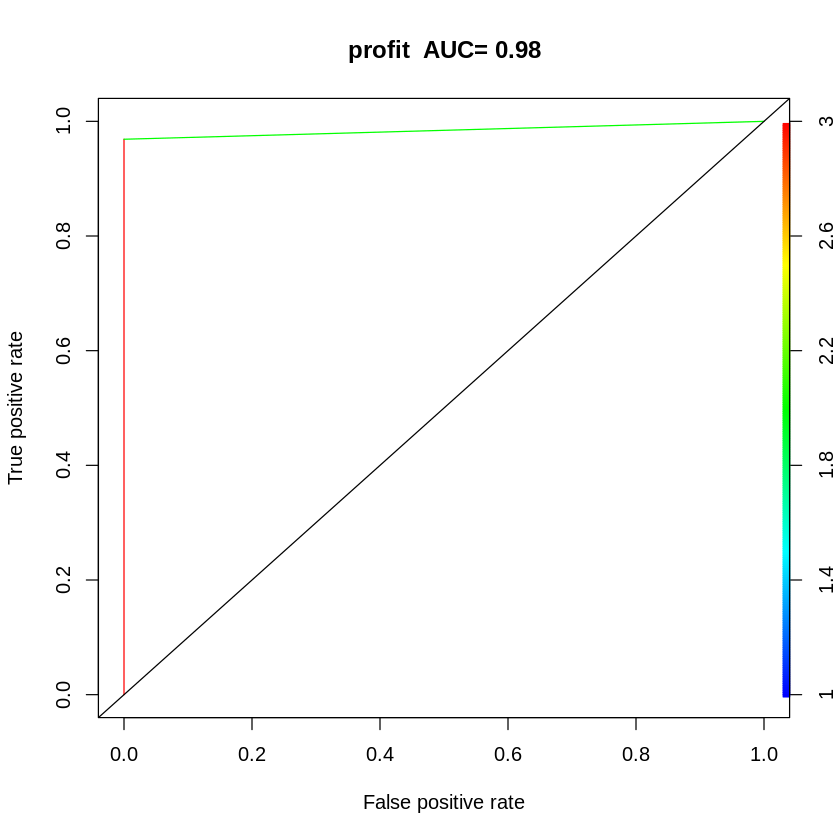

  [1] 1 1 1 0 0 1 0 0 1 0 1 0 1 0 0 1 1 1 0 1 1 1 1 0 0 0 0 0 0 0 1 0 1 0 0 1 1
 [38] 1 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 1 0 1
 [75] 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0
[112] 0 0 1 0 1 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 1 1 0 0 1 0 0 1 0
[149] 0 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0
[186] 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0
[223] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
Levels: 0 1
A prediction instance
  with 237 data pointsA performance instance
  'False positive rate' vs. 'True positive rate' (alpha: 'Cutoff')
  with 3 data points

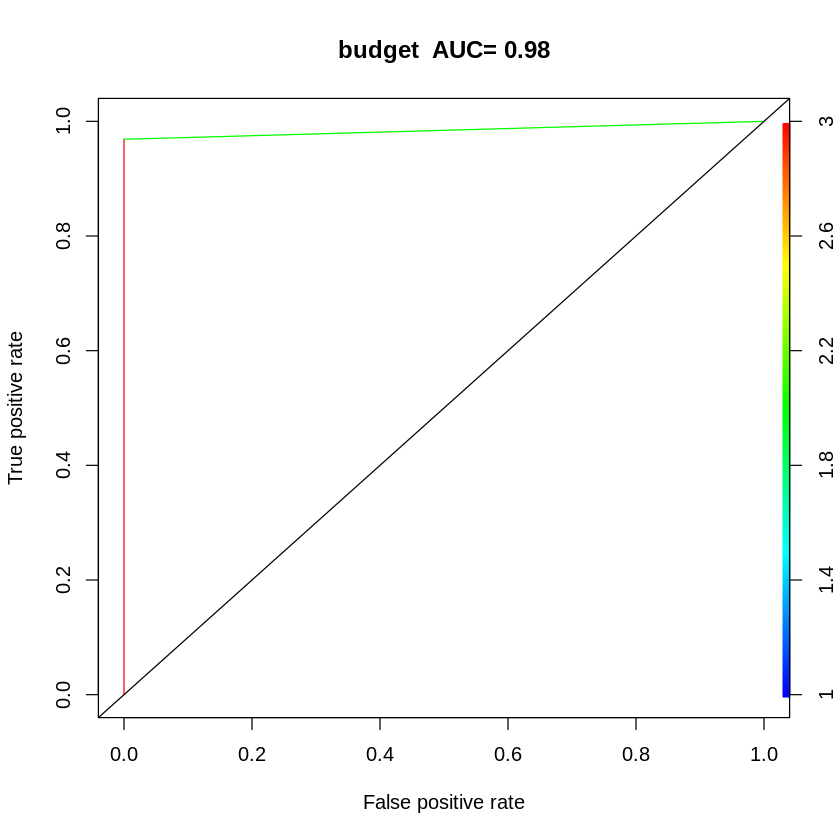

  [1] 1 1 1 0 0 1 0 0 1 0 1 0 1 0 0 1 1 1 0 1 1 1 1 0 0 0 0 0 0 0 1 0 1 0 0 1 1
 [38] 1 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 1 0 1
 [75] 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0
[112] 0 0 1 0 1 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 1 1 0 0 1 0 0 0 0
[149] 0 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0
[186] 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0
[223] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
Levels: 0 1
A prediction instance
  with 237 data pointsA performance instance
  'False positive rate' vs. 'True positive rate' (alpha: 'Cutoff')
  with 3 data points

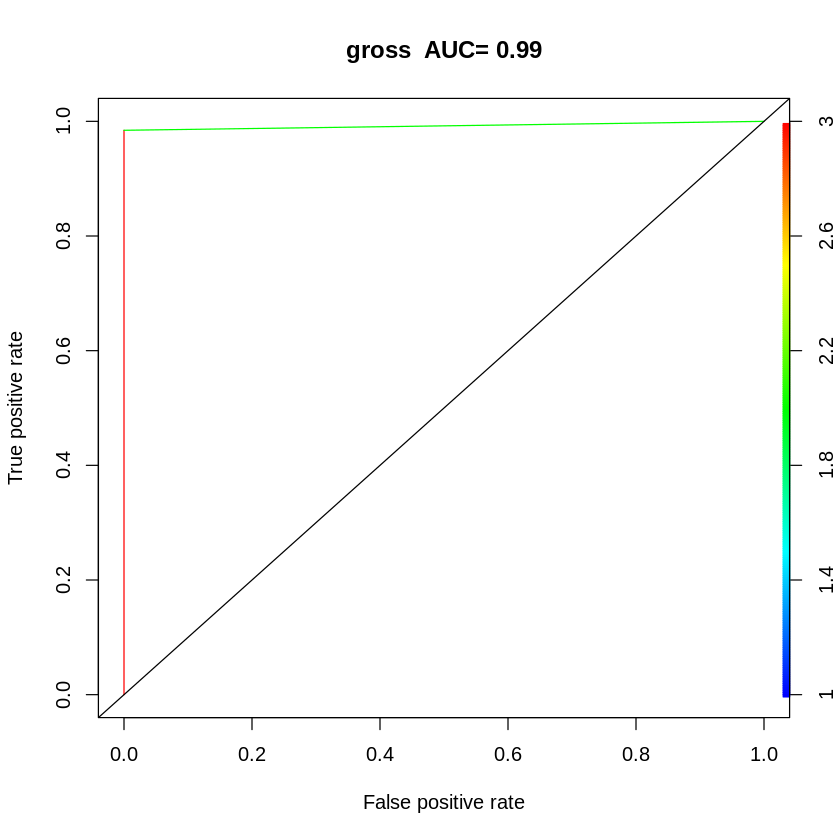

  [1] 1 1 1 0 0 1 0 0 1 0 1 0 1 0 0 1 1 1 0 1 1 1 1 0 0 0 0 0 0 0 1 0 1 0 0 1 1
 [38] 1 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 1 0 1
 [75] 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0
[112] 0 0 1 0 1 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 1 1 0 0 1 0 0 0 0
[149] 0 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0
[186] 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0
[223] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
Levels: 0 1
A prediction instance
  with 237 data pointsA performance instance
  'False positive rate' vs. 'True positive rate' (alpha: 'Cutoff')
  with 3 data points

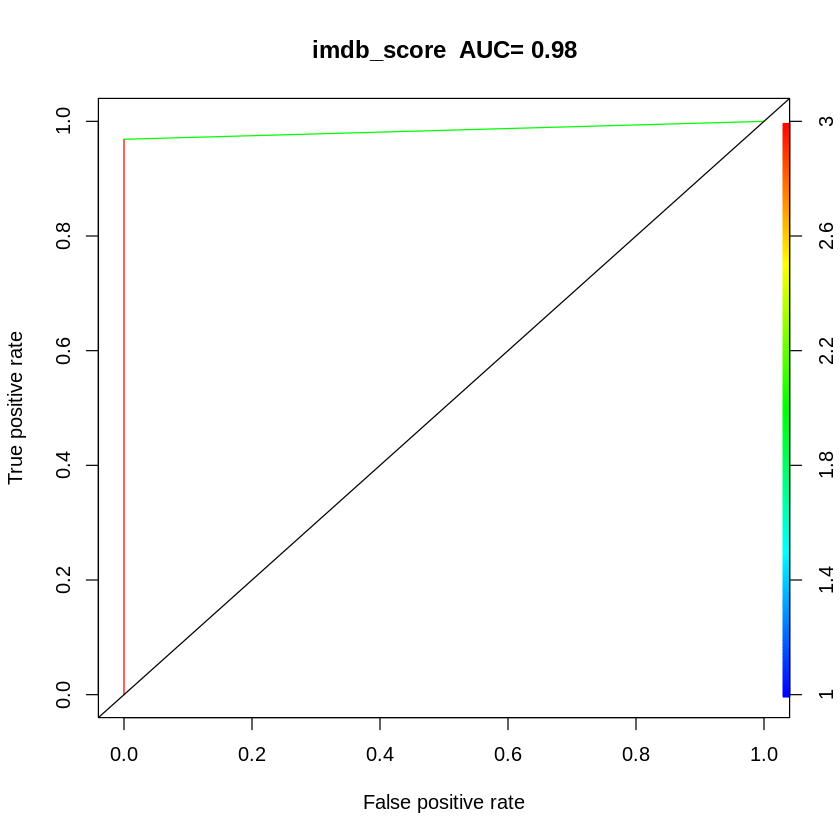

  [1] 1 1 1 0 0 1 0 0 1 0 1 0 1 0 0 1 1 1 0 1 1 1 1 0 0 0 0 0 0 0 1 0 1 0 0 1 1
 [38] 1 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 1 0 1
 [75] 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0
[112] 0 0 1 0 1 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 1 1 0 0 1 0 0 1 0
[149] 0 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0
[186] 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0
[223] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
Levels: 0 1
A prediction instance
  with 237 data pointsA performance instance
  'False positive rate' vs. 'True positive rate' (alpha: 'Cutoff')
  with 3 data points

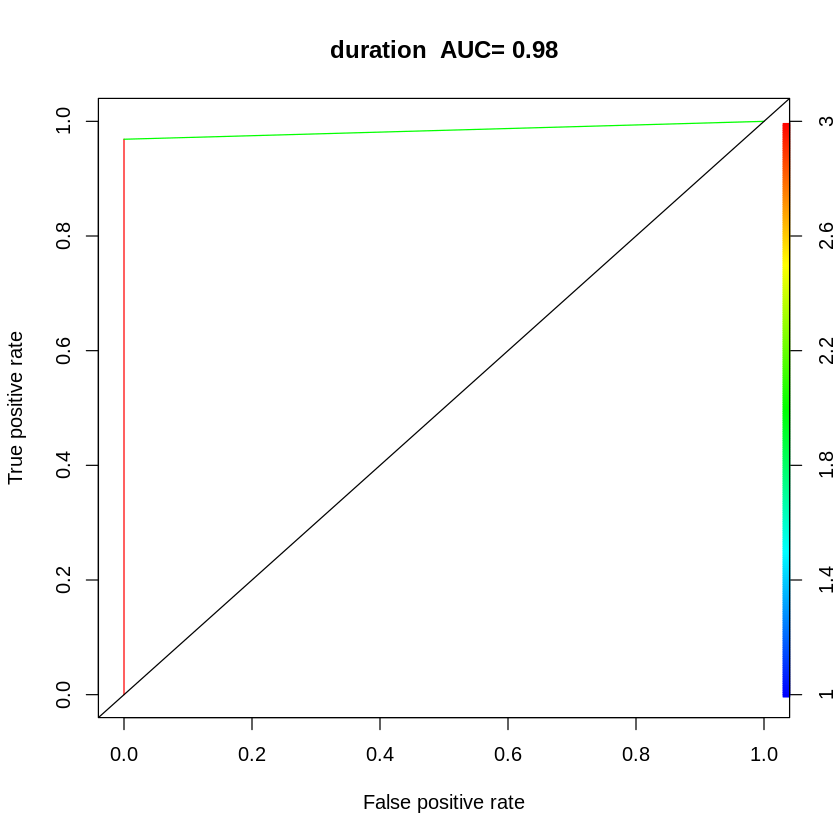

  [1] 1 1 1 0 0 1 0 0 1 0 1 0 1 0 0 1 1 1 0 1 1 1 1 0 0 0 0 0 0 0 1 0 1 0 0 1 1
 [38] 1 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 1 0 1
 [75] 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0
[112] 0 0 1 0 1 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 1 1 0 0 1 0 0 0 0
[149] 0 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0
[186] 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0
[223] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
Levels: 0 1
A prediction instance
  with 237 data pointsA performance instance
  'False positive rate' vs. 'True positive rate' (alpha: 'Cutoff')
  with 3 data points

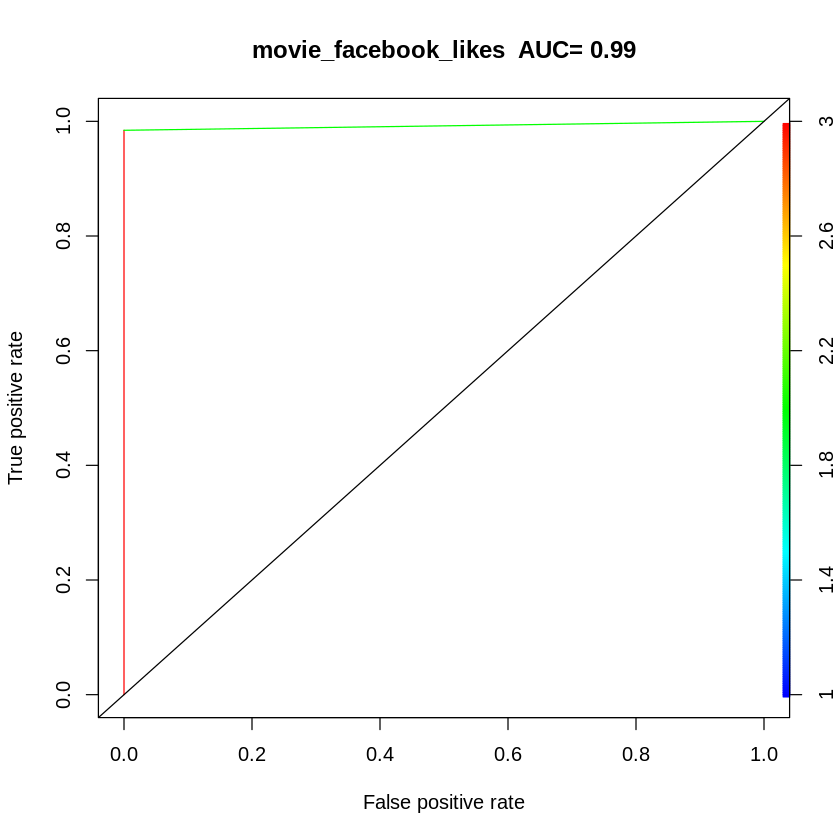

  [1] 1 1 1 0 0 1 0 0 1 0 1 0 1 0 0 1 1 1 0 1 1 1 1 0 0 0 0 0 0 0 1 0 1 0 0 1 1
 [38] 1 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 1 0 1
 [75] 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0
[112] 0 0 1 0 1 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 1 1 0 0 1 0 0 0 0
[149] 0 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0
[186] 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0
[223] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
Levels: 0 1
A prediction instance
  with 237 data pointsA performance instance
  'False positive rate' vs. 'True positive rate' (alpha: 'Cutoff')
  with 3 data points

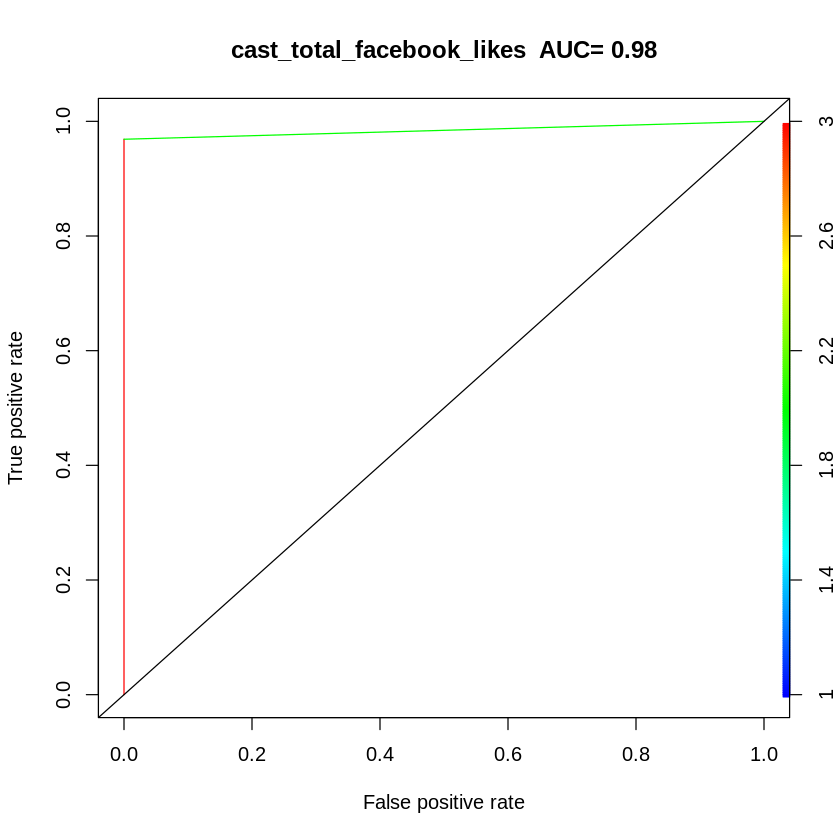

,Explicatorias,AUC
,<chr>,<dbl>
3,gross,0.9921875
6,movie_facebook_likes,0.9921875
1,profit,0.9843750
2,budget,0.9843750
4,imdb_score,0.9843750
5,duration,0.9843750
7,cast_total_facebook_likes,0.9843750
8,content_rating,0.9843750


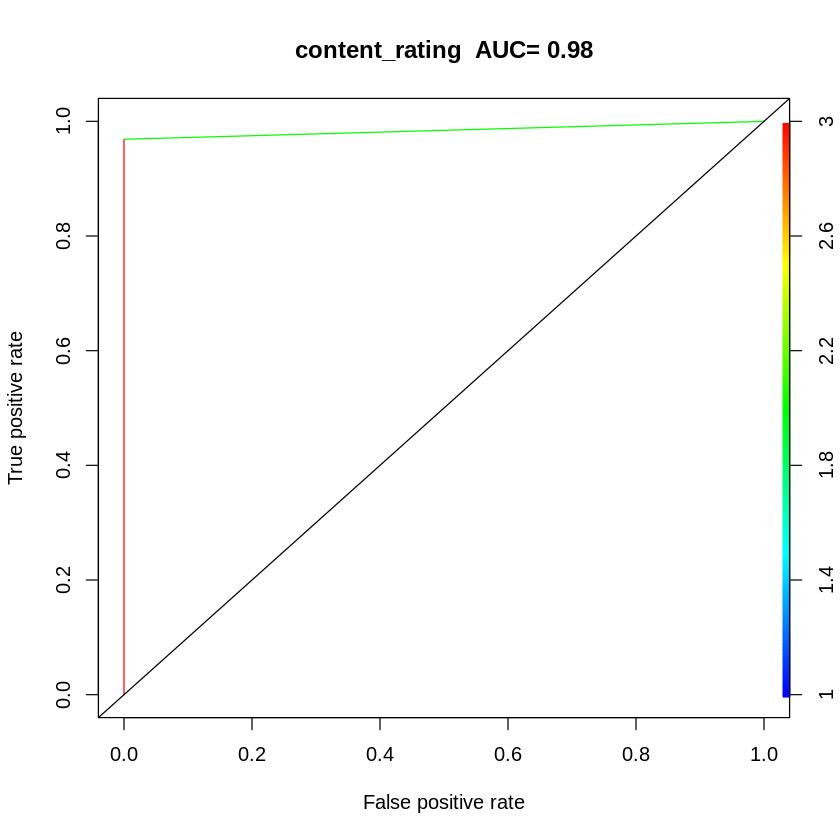

In [ ]:
corrida_roc_knn <- function (df){
    df <- dplyr::select_if(df, is.numeric)
    # df
    dima = dim(df)
    grupo.train = sample(c(0 ,1) ,dima[1],replace= TRUE, prob=c( 0.10 , 0.90))
    indices<- 1:dima[1]
    indices.train<- (indices[grupo.train ==1])

    datos.train<-df[indices.train,]
    datos.test<-df[-indices.train,]
    train.vector = datos.train[,"content_rating"]
    explicatorias <- names(df)
    auces <- c()

    for (m in 1:length(explicatorias)){

    knn.pred <- knn (datos.train, datos.test, train.vector , k = 20)
    print(knn.pred)
    predict.rocr<- prediction( as.numeric(knn.pred) , datos.test$content_rating)
    print(predict.rocr)
    pref.rocr<- performance(predict.rocr ,"tpr", "fpr")
    print(pref.rocr)
    auc.cui<- as.numeric( performance (predict.rocr , "auc")@y.values)

    auces <- c(auces, auc.cui)
    plot( pref.rocr , colorize=TRUE, type="l" , main=paste ( explicatorias[m]," AUC=",round(auc.cui,2)) )
    abline(a=0,b=1)
    }
    tabla_auc<-data.frame(explicatorias,auces)
    colnames(tabla_auc)<-c("Explicatorias", "AUC")
    # tabla_auc[order(tabla_auc$AUC),]
    tabla_auc <- tabla_auc[order(-tabla_auc$AUC),]
    # sort(x, decreasing = FALSE, na.last = TRUE)
    tabla_auc
}

#df_def=scale(df[,c("profit","budget","gross", "imdb_score", "duration","movie_facebook_likes", "cast_total_facebook_likes")])
#df_def=cbind(df_def, df["content_rating"])
#colnames(df_def)[8]="content_rating"

# 1) DATAFRAME df_PG_17 donde queda PG vs R
df_PG_17 <- df_def[df_def$content_rating %in% c("PG","R"),] # Hago binaria la variable respuesta (VR)
df_PG_17$content_rating = ifelse(df_PG_17$content_rating=="PG",1,0) # Hago entre 0 y 1 la VR
print('¿Que variables tienen valores vacios?')
#df_PG_17<- df_PG_17[!is.na(df_PG_17$facenumber_in_poster), ]
#df_PG_17 <- subset(df_PG_17, select = -aspect_ratio)

#colSums(sapply(df_PG_17, is.na))

corrida_roc_knn(df_PG_17)


#df_PG_13y17 <- df[df$content_rating %in% c("PG","R","PG-13"),]
#df_PG_13y17$content_rating[df_PG_13y17$content_rating == 'PG-13'] <- 'R'
#table(df_PG_13y17['content_rating'])
